# Progetto ML Traccia T1: Sentiment Analsysis - Matteo Pallagrosi (0338469)

# Introduzione
L'obiettivo di questo progetto è addestrare, valutare e confrontare diversi modelli di ML nella risoluzione di un task di sentiment analysis, ossia classificazione binaria del sentimento (positivo o negativo) espresso da frasi in lingua inglese. Le frasi provengono da due diversi domini applicativi: recensioni di film su IMDb e recensioni di attività commerciali su Yelp.
<br>
Lo scopo finale è quindi quello di identificare i modelli che presentano le prestazioni migliori su ciascuno dei domini, e su un dataset unificato costituito da entrambi.

 # Imports

Vengono importate diverse librerie necessarie per la corretta esecuzione del notebook.

In [2]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
## os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import csv
import regex
import random

# NLP / Text Manipulation
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Utility Functions

Sono definite alcune funzioni utili a salvare su file csv i risultati (accuratezza e f1) ottenuti dai vari modelli nel corso del notebook.

In [3]:
import csv
import os
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Nomi dei file CSV
ACC_FILE = "accuracy.csv"
F1_FILE = "f1.csv"

def init_results_files():
    
    # Inizializza i file CSV scrivendo l'intestazione.
    # Se i file esistono, verranno sovrascritti.
    
    headers = ["Model", "IMDb", "Yelp", "IMDb+Yelp"]
    
    with open(ACC_FILE, "w", newline='') as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        
    with open(F1_FILE, "w", newline='') as f:
        writer = csv.writer(f)
        writer.writerow(headers)
    
    print(f"File {ACC_FILE} e {F1_FILE} inizializzati.")

def _append_to_csv(filename, row_data):
    with open(filename, "a", newline='') as f:
        writer = csv.writer(f)
        writer.writerow(row_data)


# Salva su file i risultati ottenuti dai modelli baseline (Regressione Logistice e Naive Bayes)
def log_baseline_performance(model_name, 
                              model_imdb, X_imdb, y_imdb,
                              model_yelp, X_yelp, y_yelp,
                              model_unified, X_unified, y_unified):
    
    # Calcolo metriche per IMDb
    pred_imdb = model_imdb.predict(X_imdb)
    acc_imdb = accuracy_score(y_imdb, pred_imdb)
    f1_imdb = f1_score(y_imdb, pred_imdb, average='macro')
    
    # Calcolo metriche per Yelp
    pred_yelp = model_yelp.predict(X_yelp)
    acc_yelp = accuracy_score(y_yelp, pred_yelp)
    f1_yelp = f1_score(y_yelp, pred_yelp, average='macro')
    
    # Calcolo metriche per Unified
    pred_uni = model_unified.predict(X_unified)
    acc_uni = accuracy_score(y_unified, pred_uni)
    f1_uni = f1_score(y_unified, pred_uni, average='macro')
    
    # Scrittura su CSV
    _append_to_csv(ACC_FILE, [model_name, acc_imdb, acc_yelp, acc_uni])
    _append_to_csv(F1_FILE, [model_name, f1_imdb, f1_yelp, f1_uni])
    
    print(f"Risultati per '{model_name}' salvati su CSV.")

# Salva i risultati ottenuti dai modelli basati su rete neurale
def log_neural_performance(model_name, 
                           model_imdb, X_imdb, y_imdb,
                           model_yelp, X_yelp, y_yelp,
                           model_unified, X_unified, y_unified,
                           threshold=0.5):

    def get_metrics(model, X, y):
        pred_prob = model.predict(X, verbose=0)
        # Conversione probabilità -> classi (0 o 1)
        pred_class = (np.squeeze(pred_prob) > threshold).astype(int)
        
        y_true = y.values if hasattr(y, 'values') else y
        
        return accuracy_score(y_true, pred_class), f1_score(y_true, pred_class, average='macro')

    # Calcolo metriche
    acc_imdb, f1_imdb = get_metrics(model_imdb, X_imdb, y_imdb)
    acc_yelp, f1_yelp = get_metrics(model_yelp, X_yelp, y_yelp)
    acc_uni, f1_uni = get_metrics(model_unified, X_unified, y_unified)
    
    # Scrittura su CSV
    _append_to_csv(ACC_FILE, [model_name, acc_imdb, acc_yelp, acc_uni])
    _append_to_csv(F1_FILE, [model_name, f1_imdb, f1_yelp, f1_uni])
    
    print(f"Risultati per '{model_name}' salvati su CSV.")

In [4]:
init_results_files()

File accuracy.csv e f1.csv inizializzati.


# Data Preprocessing

In questa sezione viene realizzato il caricamento e pre-processamento dei dati, necessario per predisporli come input ai diversi modelli di machine learning addestrati e valutati nel corso del notebook.

## Loading Data

Le recensioni sono caricate a partire da due distinti file di testo. Oltre ai due dataset caricati separatamente, viene anche creato un dataset unificato costituito sia dalle recensioni di film che di attività commerciali, con lo scopo di valutare il comportamento dei modelli quando sono addestrati su molteplici domini contemporaneamente.
<br>
Sono anche visualizzate le prime 10 frasi di questo dataset unificato, per mostrare esempi di recensioni sia da IMDb che da Yelp. Ad ogni frase è associato il sentimento espresso (1=positivo, 0=negativo). Le frasi nel dataset unificato sono inoltre arricchite con l'informazione relativa al dominio di appartenenza.

In [5]:
imdb = pd.read_csv(
    "sentiment_labelled_sentences/imdb_labelled.txt",
    sep="\t",          
    header=None,       
    names=["review", "sentiment"],
    engine="python",
    quoting=csv.QUOTE_NONE
)

yelp = pd.read_csv(
    "sentiment_labelled_sentences/yelp_labelled.txt",
    sep="\t",
    header=None,
    names=["review", "sentiment"],
    engine="python",
    quoting=csv.QUOTE_NONE
)

imdb["domain"] = "imdb"
yelp["domain"] = "yelp"

data = pd.concat([imdb, yelp], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data.head(10)

,review,sentiment,domain
0,"This place is pretty good, nice little vibe in...",1,yelp
1,I would give this television series a 10 plus ...,1,imdb
2,Everything was gross.,0,yelp
3,"One of the most boring,pointless movies I have...",0,imdb
4,"I hate to disagree with my fellow Yelpers, but...",0,yelp
5,Stopped by this place while in Madison for the...,1,yelp
6,This movie is great--especially if you enjoy v...,1,imdb
7,Ryan's Bar is definitely one Edinburgh establi...,0,yelp
8,One character is totally annoying with a voice...,0,imdb
9,"A couple of months later, I returned and had a...",1,yelp


## Basic checks dataset

Si controllano le dimensioni dei diversi dataset, e si verifica che la dimensione del dataset unificato sia la somma delle dimensioni dei due dataset separati IMDb e Yelp.

In [6]:
print("Dimensione dataset IMDb: ", imdb.shape)
print("\nDistribuzione del sentiment:\n", imdb["sentiment"].value_counts())

Dimensione dataset IMDb:  (1000, 3)

Distribuzione del sentiment:
 sentiment
0    500
1    500
Name: count, dtype: int64


In [7]:
print("Dimensione dataset Yelp: ", yelp.shape)
print("\nDistribuzione del sentiment:\n", yelp["sentiment"].value_counts())

Dimensione dataset Yelp:  (1000, 3)

Distribuzione del sentiment:
 sentiment
1    500
0    500
Name: count, dtype: int64


In [8]:
print("Dimensione dataset unificato: ", data.shape)
print("\nDistribuzione del sentiment:\n", data["sentiment"].value_counts())

Dimensione dataset unificato:  (2000, 3)

Distribuzione del sentiment:
 sentiment
1    1000
0    1000
Name: count, dtype: int64


In [9]:
# Check di valori nulli
data.isnull().sum()

review       0
sentiment    0
domain       0
dtype: int64

Da questi controlli si osserva che i due domini presentano 1000 frasi ciascuno, equamente ripartite nelle due classi positiva e negativa, quindi tutti i dataset risultano perfettamente bilanciati.
<br>
Inoltre non sono presenti valori nulli su nessuna delle colonne del dataset (nè sulle recensioni, nè sui valori target).

## Cleaning Data

Con questa fase di pre-processamento vengono rimossi i caratteri speciali e HTML, non significativi per la predizione del sentimento espresso dal testo, e viene convertito tutto il testo in lettere minuscole, favorendo inoltre una riduzione di dimensione del vocabolario e una potenziale maggior frequenza di un certo termine all'interno delle recensioni (poichè termini uguali ma con iniziali in maiuscolo e minusolo sono ricondotti alla stessa parola).
<br>
Viene quindi mostrato il risultato di questo pre-processamento, mostrando le prime 10 frasi del dataset unificato.

In [10]:
def cleanText(text):
    # Remove HTML tags
    text = regex.sub(r"<[^<]+?>", "", text)
    
    # Remove Special chars
    text = regex.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    # Convet to LowerCase
    text = text.lower()

    # Remove extra spaces
    text = regex.sub(r"\s+", " ", text).strip()
    
    return text

In [11]:
# Applying the function to data
imdb["review"] = imdb["review"].apply(cleanText)

yelp["review"] = yelp["review"].apply(cleanText)

data["review"] = data["review"].apply(cleanText)
data.head(10)

,review,sentiment,domain
0,this place is pretty good nice little vibe in ...,1,yelp
1,i would give this television series a 10 plus ...,1,imdb
2,everything was gross,0,yelp
3,one of the most boring pointless movies i have...,0,imdb
4,i hate to disagree with my fellow yelpers but ...,0,yelp
5,stopped by this place while in madison for the...,1,yelp
6,this movie is great especially if you enjoy vi...,1,imdb
7,ryan s bar is definitely one edinburgh establi...,0,yelp
8,one character is totally annoying with a voice...,0,imdb
9,a couple of months later i returned and had an...,1,yelp


## StopWords Removal

Sono quindi rimosse tutte le stopwords, ossia parole comuni non significative ai fini della classificazione, come ad esempio le congiunzioni, gli articoli e le preposizioni, in quanto non caratterizzanti uno specifico sentimento espresso dalla frase.

In [12]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

# Get list of stopwords from nltk
stopword_list = stopwords.words('english')

# Tokenize and Remove StopWords
def remove_stopwords(text):
    tokens = [token.strip() for token in word_tokenize(text)]
    filtered_tokens = [token for token in tokens if token.lower() not in stopword_list]
    filtered_text = ' '.join(filtered_tokens)

    return filtered_text

[nltk_data] Downloading package stopwords to /home/matteo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/matteo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/matteo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
imdb['review'] = imdb['review'].apply(remove_stopwords)

yelp['review'] = yelp['review'].apply(remove_stopwords)

data['review'] = data['review'].apply(remove_stopwords)
data.head(10)

,review,sentiment,domain
0,place pretty good nice little vibe restaurant,1,yelp
1,would give television series 10 plus could,1,imdb
2,everything gross,0,yelp
3,one boring pointless movies ever seen,0,imdb
4,hate disagree fellow yelpers husband disappoin...,0,yelp
5,stopped place madison ironman friendly kind staff,1,yelp
6,movie great especially enjoy visual arts,1,imdb
7,ryan bar definitely one edinburgh establishmen...,0,yelp
8,one character totally annoying voice gives fee...,0,imdb
9,couple months later returned amazing meal,1,yelp


## Lemmatization
Si decide di utilizzare la lemmatization per riportare i termini alla loro forma base (ossia al lemma, come presente in un dizionario). Viene utilizzata questa tecnica in luogo dello stemming, utilizzato frequentemente nei task di NLP per il pre-processamento dei dati. A differenza dello stemming, che riporta ogni termine alla sua base semantica, non producendo necessariamente una parola valida dal punto di vista grammaticale o semantico (es. flying -> fli), la lemmatization produce sempre termini corretti, presenti nel dizionario della lingua di riferimento, tenendo conto della Part of Speech (POS, come verbo, sostantivo o aggettivo) a cui il termine appartiene per costruire il lemma corrispondente (es. flying (come verbo) -> fly)).
<br>
Con questa tecnica è possibile quindi costruire frasi che siano semanticamente e grammaticalmente sensate anche a seguito del pre-processamento, favorendo specialmente quei modelli che cercando di estrarre la semantica dai termini in input costruendo degli embedding significativi.

In [14]:
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package wordnet to /home/matteo/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/matteo/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/matteo/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [15]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return wordnet.VERB
    elif treebank_tag.startswith("N"):
        return wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_sentence(text):
    tokens = word_tokenize(text.lower())
    pos_tags = pos_tag(tokens)

    lemmas = [
        lemmatizer.lemmatize(token, get_wordnet_pos(pos))
        for token, pos in pos_tags
    ]

    return " ".join(lemmas)

In [16]:
imdb["review"] = imdb["review"].apply(lemmatize_sentence)

yelp["review"] = yelp["review"].apply(lemmatize_sentence)

data["review"] = data["review"].apply(lemmatize_sentence)
data.head(10)

,review,sentiment,domain
0,place pretty good nice little vibe restaurant,1,yelp
1,would give television series 10 plus could,1,imdb
2,everything gross,0,yelp
3,one boring pointless movie ever see,0,imdb
4,hate disagree fellow yelpers husband disappoin...,0,yelp
5,stopped place madison ironman friendly kind staff,1,yelp
6,movie great especially enjoy visual art,1,imdb
7,ryan bar definitely one edinburgh establishmen...,0,yelp
8,one character totally annoying voice give feel...,0,imdb
9,couple month later return amazing meal,1,yelp


# Dataset Preparation

Ciascuno dei dataset (IMDb, Yelp e dataset unificato dei due domini) viene suddiviso in training set, validation set e test set secondo una divisione 70%-15%-15%. La scelta della dimensione dei set è dovuto ad un bilanciamento tra training e validation/testing, poichè partendo da dataset iniziali di dimensioni ridotte, si è cercato di favorire un maggior numero di esempi nel training set, senza però che questo comportasse un numero insufficiente di esempi in validation e test set, e quindi dei risultati sulla capacità di generalizzare dei modelli che non fossero adeguatamente significativi in quanto prodotti su pochi esempi (una suddivisione 80-10-10 avrebbe prodotto troppi pochi esempi su cui valutare le capacità di generalizzazione, al contrario una suddivisione 60-20-20 avrebbe prodotto un training set troppo ristretto).
<br>
Ciascun set è stato costruito bilanciando il numero di esempi della classe positiva e della classe negativa, in modo da produrre una loro equa rappresentazione sia nel training che nel validation e test set.
<br>
Per ogni dominio viene quindi mostrato come sono ripartiti gli esempi nei diversi set.

Splitting dataset imdb:

In [17]:
#Splitting del dataset imdb in train+validation (85%) e test set(15%)
X_train_val_text_imdb, X_test_text_imdb, y_train_val_imdb, y_test_imdb = train_test_split(
    imdb["review"],
    imdb["sentiment"],
    test_size=0.15,
    random_state=42,
    stratify=imdb["sentiment"]
)

#Splitting di train+validation imdb in training set (70%) e validation set (15%)
X_train_text_imdb, X_val_text_imdb, y_train_imdb, y_val_imdb = train_test_split(
    X_train_val_text_imdb,
    y_train_val_imdb,
    test_size=0.1762,
    random_state=42,
    stratify=y_train_val_imdb
)

In [18]:
train_df = pd.DataFrame({"review": X_train_text_imdb, "sentiment": y_train_imdb})
val_df   = pd.DataFrame({"review": X_val_text_imdb,   "sentiment": y_val_imdb})
test_df  = pd.DataFrame({"review": X_test_text_imdb,  "sentiment": y_test_imdb})

# Mostra il numero di esempi e la distribuzione in ogni set
def check_dataset_split(df, name):
    print(f"--- {name} ---")
    print(f"Numero totale esempi: {len(df)}")
    print("Distribuzione classi:")
    print(df['sentiment'].value_counts(normalize=True))  # proporzioni
    print()

check_dataset_split(train_df, "Training set imdb")
check_dataset_split(val_df, "Validation set imdb")
check_dataset_split(test_df, "Test set imdb")

# Mostra la distribuzione degli esempi nei tre set
total = len(imdb)
print("Percentuali rispetto al dataset originale:")
print(f"Train: {len(train_df)/total:.2%}")
print(f"Validation: {len(val_df)/total:.2%}")
print(f"Test: {len(test_df)/total:.2%}")

--- Training set imdb ---
Numero totale esempi: 700
Distribuzione classi:
sentiment
1    0.5
0    0.5
Name: proportion, dtype: float64

--- Validation set imdb ---
Numero totale esempi: 150
Distribuzione classi:
sentiment
0    0.5
1    0.5
Name: proportion, dtype: float64

--- Test set imdb ---
Numero totale esempi: 150
Distribuzione classi:
sentiment
0    0.5
1    0.5
Name: proportion, dtype: float64

Percentuali rispetto al dataset originale:
Train: 70.00%
Validation: 15.00%
Test: 15.00%


Splitting dataset yelp:

In [19]:
#Splitting del dataset yelp in train+validation (85%) e test set(15%)
X_train_val_text_yelp, X_test_text_yelp, y_train_val_yelp, y_test_yelp = train_test_split(
    yelp["review"],
    yelp["sentiment"],
    test_size=0.15,
    random_state=42,
    stratify=yelp["sentiment"]
)

#Splitting di train+validation yelp in training set (70%) e validation set (15%)
X_train_text_yelp, X_val_text_yelp, y_train_yelp, y_val_yelp = train_test_split(
    X_train_val_text_yelp,
    y_train_val_yelp,
    test_size=0.1762,
    random_state=42,
    stratify=y_train_val_yelp
)

In [20]:
train_df = pd.DataFrame({"review": X_train_text_yelp, "sentiment": y_train_yelp})
val_df   = pd.DataFrame({"review": X_val_text_yelp,   "sentiment": y_val_yelp})
test_df  = pd.DataFrame({"review": X_test_text_yelp,  "sentiment": y_test_yelp})

# Mostra il numero di esempi e la distribuzione in ogni set
check_dataset_split(train_df, "Training set yelp")
check_dataset_split(val_df, "Validation set yelp")
check_dataset_split(test_df, "Test set yelp")

# Mostra la distribuzione degli esempi nei tre set
total = len(yelp)
print("Percentuali rispetto al dataset originale:")
print(f"Train: {len(train_df)/total:.2%}")
print(f"Validation: {len(val_df)/total:.2%}")
print(f"Test: {len(test_df)/total:.2%}")

--- Training set yelp ---
Numero totale esempi: 700
Distribuzione classi:
sentiment
1    0.5
0    0.5
Name: proportion, dtype: float64

--- Validation set yelp ---
Numero totale esempi: 150
Distribuzione classi:
sentiment
0    0.5
1    0.5
Name: proportion, dtype: float64

--- Test set yelp ---
Numero totale esempi: 150
Distribuzione classi:
sentiment
0    0.5
1    0.5
Name: proportion, dtype: float64

Percentuali rispetto al dataset originale:
Train: 70.00%
Validation: 15.00%
Test: 15.00%


Relativamente al dataset unificato sui due domini, è stato realizzato, oltre al bilanciamento sulle classi target, anche un bilanciamento sul numero di esempi per ogni dominio presenti nei set unificati. Ciò comporta che nel training set unificato sono presente in egual numero esempi del dominio IMDb (700) e del dominio Yelp (700), analogamente per validation (150-150) e test set (150-150). Questo bilanciamento è stato realizzato in quanto una equa rappresentazione dei domini nel training set permette potenzialmente di ottenere modelli che presentano migliori capacità di generalizzare su entrambi i domini (un training set sbilanciato produrrebbe un modello più abile a predirre correttamente il sentimento espresso da recensioni di un certo dominio piuttosto che l'altro). Sono stati realizzati esperimenti con un training set sbilanciato, non riportati per brevità nel notebook, per confermare i vantaggi del training set bilanciato sui domini.
<br>
Il bilanciamento sia rispetto alla classe target che al dominio è realizzato aggiungengo al dataset unificato una "chiave di stratificazione" prodotta combinando il campo dominio con il campo sentiment, e rispetto al quale suddividere equamente gli esempi in training, validation e test set.
<br>
La costruzione di un dataset unificato, oltre che i datataset separati dei singoli domini, è conseguenza della volontà di studiare se un training set più ampio e che spazia su domini diversi può migliorare le capacità di generalizzazione dei diversi modelli.

Splitting dataset unificato:

In [21]:
data["stratify_key"] = data["domain"] + "_" + data["sentiment"].astype(str)

X_train_val_text, X_test_text, y_train_val, y_test = train_test_split(
    data["review"],
    data["sentiment"],
    test_size=0.15,
    random_state=42,
    stratify=data["stratify_key"]
)

train_val_df = data.loc[X_train_val_text.index].copy()

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_val_text,
    y_train_val,
    test_size=0.1762,
    random_state=42,
    stratify=train_val_df["stratify_key"]
)

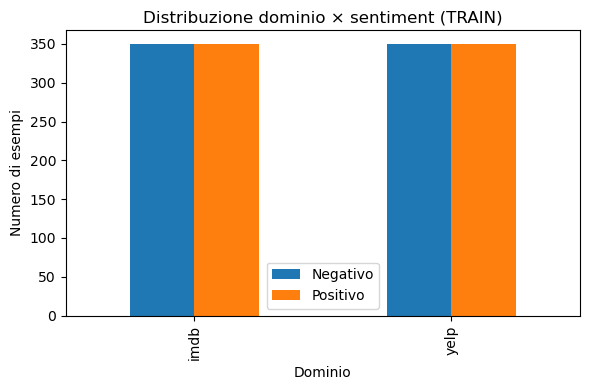

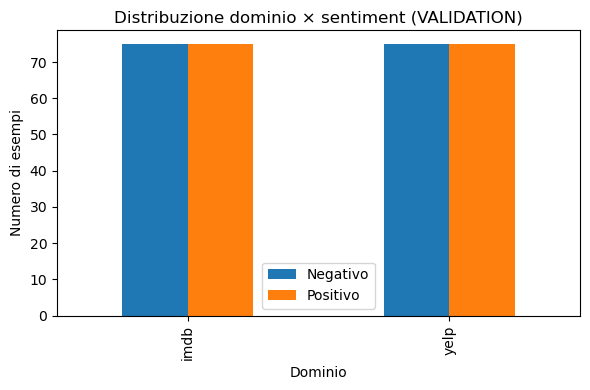

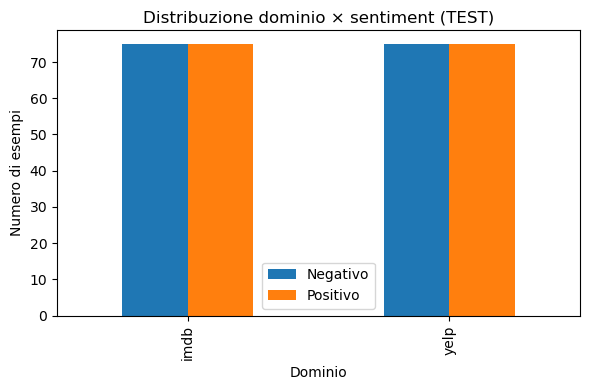

In [22]:
def plot_balance(X, y, title):
    df = pd.DataFrame({
        "domain": data.loc[X.index, "domain"],
        "sentiment": y
    })

    counts = pd.crosstab(df["domain"], df["sentiment"])

    counts.plot(
        kind="bar",
        figsize=(6, 4)
    )

    plt.title(title)
    plt.xlabel("Dominio")
    plt.ylabel("Numero di esempi")
    plt.legend(["Negativo", "Positivo"])
    plt.tight_layout()
    plt.show()

plot_balance(X_train_text, y_train, "Distribuzione dominio × sentiment (TRAIN)")
plot_balance(X_val_text, y_val, "Distribuzione dominio × sentiment (VALIDATION)")
plot_balance(X_test_text, y_test, "Distribuzione dominio × sentiment (TEST)")

I grafici mostrano l'equa ripartizione degli esempi rispetto al dominio e al sentimet per ogni set costruito.

# Regressione Logistica

Come primo modello baseline viene proposta la Regressione Logistica. Le frasi vengono fornite in input al modello sottoforma di vettori prodotti utilizzando una rappresentazione che utilizza TF-IDF, preferita al Bag Of Word model (che tiene solo conto delle occorrenze dei termini), in quanto la prima costruisce un vettore delle dimensioni del vocabolario, e per ogni termine assegna un peso proporzionale alla frequenza del termine all'interno della frase (tf), ma tenendo conto anche della rarità del termine stesso nel corpus di frasi considerato (idf), riuscendo quindi a distinguere maggiormente termini frequenti perchè significativi per la frase considerata, rispetto ai termini frequenti perchè parole di uso comune nella lingua.
<br>
La vettorizzazione prevede dapprima la costruzione di un vocabolario a partire dai soli esempi presenti nel training set (costruire il vocabolario osservando anche gli esempi del validation e test set usati rispettivamente per il tuning e per valutare le capacità di generalizzare del modello rappresenterebbe una forma di "leakage" sui dati, producendo un modello che durante l'addestramento guarda già a ciò che è presente nei dati di test). Per tale motivo si utilizza il metodo fit_transform sul training set, che costruisce il vocabolario oltre a vettorizzare le frasi, per poi usare transform al fine di vettorizzare gli altri due set usando il vocabolario già costruito.

In [23]:
#vettorizzazione dataset imdb
vect_imdb = TfidfVectorizer()
X_train_imdb = vect_imdb.fit_transform(X_train_text_imdb)
X_val_imdb = vect_imdb.transform(X_val_text_imdb)
X_test_imdb = vect_imdb.transform(X_test_text_imdb)

#vettorizazzione dataset yelp
vect_yelp = TfidfVectorizer()
X_train_yelp = vect_yelp.fit_transform(X_train_text_yelp)
X_val_yelp = vect_yelp.transform(X_val_text_yelp)
X_test_yelp = vect_yelp.transform(X_test_text_yelp)

#vettorizzazione dataset unificato
vect = TfidfVectorizer()
X_train = vect.fit_transform(X_train_text)
X_val = vect.transform(X_val_text)
X_test = vect.transform(X_test_text)

In questa prima fase si realizza il tuning dei parametri della regressione logistica. In particolare si considera l'algoritmo utilizzato per risolvere il problema di ottimizzazione ("solver"), l'inverso del fattore di regolarizzazione ("C", più è piccolo, più forte è la regolarizzazione), e che tipo di regolarizzazione applicare ("l1_ratio"). Si sottolinea come ogni tipo di regolarizzazione può essere utilizzata solo con certi solver, come previsto dall'implementazione del modello fornita da scikit-learn.
<br>
Per il tuning dei parametri si utilizza la cross validation, e quindi non si utilizza in questo caso il validation set costruito precedentemente, che invece viene utilizzato come ulteriore dataset su cui valutare le capacità di generalizzazione del modello oltre al test set. Si è deciso di non unificare questo validation set con il training set in modo da addestrare tutti i modelli (anche quelli successivi che invece utilizzano il validation set) sullo stesso training set, per un confronto equo delle performance.
<br>
Nella cross validation si è osservato che utilizzare 5 fold piuttosto che 3 fold permette di ottenere modelli che generalizzano leggermente meglio (esperimento non inserito nel notebook per brevità), poichè utilizzare più fold implica addestrare per ogni split temporale su un maggior numero di dati (k-1 fold), ottenendo un modello valutato sul fold rimanente (di dimensioni inferiore nel caso 5-fold rispetto a 3-fold). Alla fine della cross-validation, il modello viene riaddestrato sull'intero training set utilizzando i parametri migliori.

Inizialmente addestriamo e valutiamo il modello solo sul dominio IMDb. Per rendere gli esperimenti ripetibili nelle diverse run viene utilizzato (e lo stesso accade nel seguito del notebook) un seed come stato iniziale della randomizzazione.

In [24]:
lr_imdb = LogisticRegression(random_state=42, max_iter=10000)

lr_yelp = LogisticRegression(random_state=42, max_iter=10000)

lr = LogisticRegression(random_state=42, max_iter=10000)

param_grid = [

    # L2 regularization (equivalente a penalty='l2')
    {
        'solver': ['saga', 'newton-cg', 'lbfgs', 'sag', 'newton-cholesky'],
        'C': [0.01, 0.1, 1, 10, 100],
        'l1_ratio': [0]
    },

    # L1 regularization (equivalente a penalty='l1')
    {
        'solver': ['saga'],
        'C': [0.01, 0.1, 1, 10, 100],
        'l1_ratio': [1]
    },

    # Elastic Net
    {
        'solver': ['saga'],
        'C': [0.01, 0.1, 1, 10, 100],
        'l1_ratio': [0.3, 0.5, 0.7]
    },
]

grid_search_imdb = GridSearchCV(estimator=lr_imdb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search_yelp = GridSearchCV(estimator=lr_yelp, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

Addestriamo e valutiamo sul solo dominio imdb.

In [25]:
# Grid search sul solo dominio imdb
grid_search_imdb.fit(X_train_imdb, y_train_imdb)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'l1_ratio': [0], 'solver': ['saga', 'newton-cg', ...]}, {'C': [0.01, 0.1, ...], 'l1_ratio': [1], 'solver': ['saga']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [26]:
# Migliori iperparametri trovati per il dominio imdb
print("Best parameters found for Logistic Regression on imdb dataset: ", grid_search_imdb.best_params_)

Best parameters found for Logistic Regression on imdb dataset:  {'C': 1, 'l1_ratio': 0, 'solver': 'newton-cg'}


In [27]:
def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)

    print(f"\n{name} SET")
    print("Accuracy:", accuracy_score(y, y_pred))
    print("\nClassification Report:")
    print(classification_report(y, y_pred))

In [28]:
best_lr_imdb = grid_search_imdb.best_estimator_

evaluate_model(best_lr_imdb, X_val_imdb, y_val_imdb, "IMDB VALIDATION")
evaluate_model(best_lr_imdb, X_test_imdb, y_test_imdb, "IMDB TEST")


IMDB VALIDATION SET
Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.83        75
           1       0.81      0.88      0.85        75

    accuracy                           0.84       150
   macro avg       0.84      0.84      0.84       150
weighted avg       0.84      0.84      0.84       150


IMDB TEST SET
Accuracy: 0.8266666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        75
           1       0.83      0.83      0.83        75

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.83      0.83      0.83       150



Addestriamo e valutiamo sul solo dominio yelp.

In [29]:
# Grid search sul solo dominio yelp
grid_search_yelp.fit(X_train_yelp, y_train_yelp)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'l1_ratio': [0], 'solver': ['saga', 'newton-cg', ...]}, {'C': [0.01, 0.1, ...], 'l1_ratio': [1], 'solver': ['saga']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [30]:
# Migliori iperparametri trovati sul dominio yelp.
print("Best parameters found for Logistic Regression on yelp dataset: ", grid_search_yelp.best_params_)

Best parameters found for Logistic Regression on yelp dataset:  {'C': 10, 'l1_ratio': 0.5, 'solver': 'saga'}


In [31]:
best_idx = grid_search_yelp.best_index_

mean_acc = grid_search_yelp.cv_results_["mean_test_score"][best_idx]
std_acc  = grid_search_yelp.cv_results_["std_test_score"][best_idx]

print(f"Cross-validation accuracy: {mean_acc:.3f} ± {std_acc:.3f}")

Cross-validation accuracy: 0.764 ± 0.014


In [32]:
best_lr_yelp = grid_search_yelp.best_estimator_

evaluate_model(best_lr_yelp, X_val_yelp, y_val_yelp, "YELP VALIDATION")
evaluate_model(best_lr_yelp, X_test_yelp, y_test_yelp, "YELP TEST")


YELP VALIDATION SET
Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        75
           1       0.84      0.84      0.84        75

    accuracy                           0.84       150
   macro avg       0.84      0.84      0.84       150
weighted avg       0.84      0.84      0.84       150


YELP TEST SET
Accuracy: 0.7533333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74        75
           1       0.74      0.79      0.76        75

    accuracy                           0.75       150
   macro avg       0.75      0.75      0.75       150
weighted avg       0.75      0.75      0.75       150



Addestriamo e valutiamo sul dataset unificato.

In [33]:
# Grid search sul dataset unificato
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'l1_ratio': [0], 'solver': ['saga', 'newton-cg', ...]}, {'C': [0.01, 0.1, ...], 'l1_ratio': [1], 'solver': ['saga']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [34]:
# Migliori iperparametri trovati
print("Best parameters found for Logistic Regression: ", grid_search.best_params_)

Best parameters found for Logistic Regression:  {'C': 1, 'l1_ratio': 0, 'solver': 'lbfgs'}


In [35]:
best_lr = grid_search.best_estimator_

evaluate_model(best_lr, X_val, y_val, "VALIDATION")
evaluate_model(best_lr, X_test, y_test, "TEST")


VALIDATION SET
Accuracy: 0.8033333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       150
           1       0.79      0.83      0.81       150

    accuracy                           0.80       300
   macro avg       0.80      0.80      0.80       300
weighted avg       0.80      0.80      0.80       300


TEST SET
Accuracy: 0.81

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       150
           1       0.83      0.77      0.80       150

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.81      0.81      0.81       300



La regressione logistica con tuning degli iperparametri ottiene prestazioni discrete su entrambi i domini e sul dataset unificato. I valori di accuratezza sul test set risultano 82.7% per il dominio imdb, 75.3% per il dominio yelp, e 81% sul dataset unificato. Sia sul dataset imdb che quello unificato le prestazioni di generalizzazione ottenuto su set di validazione (usato come se fosse un ulteriore test set) e test set vero e proprio risultano coerenti, mentre si osserva uno scostamento nel caso del dominio yelp (75.3% sul test set e 84% sul validation set). Questa discrepanza può essere dovuta a diversi fattori:
- validation e test set hanno un numero ristretto di esempi ciascuno (150 esempi in ogni set), ciò significa che poche predizioni corrette in più permettono di modificare l'accuratezza notevolmente (ciò è normale considerando la variabilità statistica che sussiste tra i diversi set). Con dataset piccoli queste oscillazioni sono quindi comuni.
- il test set potrebbe essere più complesso da predire, anche se bilanciato tra classe positiva e negativa, ossia potrebbe contenere (data la casualità dello splitting) un numero maggiore di frasi ambigue, sarcastiche, rumorose rispetto al validation set, che invece potrebbe contenere frasi più vicine a quelle che il modello ha osservato nel training set.
<br>
La correttezza della valutazione sul test set può essere però confermata osservando l'andamento delle prestazioni ottenute dal modello durante la cross validation, dove media e deviazione standard dell'accuratezza ottenuta sui vari fold di validazione risulta essere 0.764 ± 0.014, quindi coerente con le prestazioni ottenute sul test set.
<br>
Gli iperparametri ottimali individuati nel caso di dataset unificato e imdb risultano simili (C=1 e l1_ratio = 0 in entrambi i casi, cambia il solver), mentre sul dominio yelp la grid search produce un fattore di regolarizzazione numericamente più alto (C=10, e quindi una regolarizzazione meno forte) e l1_ratio = 0.5 (ossia Elastic Net come tecnica di regolarizzazione, che combina le tecniche L1 e L2).

Andiamo a valutare come il modello addestrato sul dataset unificato si comporta sui singoli domini.

In [36]:
def print_domain_accuracy(model, X_input, y_true, X_original_text, data_df):
    # Ottiene le predizioni
    y_pred = model.predict(X_input)
    
    analysis_df = pd.DataFrame({
        'Is_Correct': y_true == y_pred,
        'Domain': data_df.loc[X_original_text.index, 'domain']
    })
    
    # Raggruppa per dominio e calcola le statistiche
    domain_stats = analysis_df.groupby('Domain')['Is_Correct'].agg(['sum', 'count', 'mean'])
    
    print(f"\nDettaglio prestazioni per dominio:")
    for domain in domain_stats.index:
        num_correct = int(domain_stats.loc[domain, 'sum'])
        num_total = int(domain_stats.loc[domain, 'count'])
        accuracy_pct = domain_stats.loc[domain, 'mean'] * 100
        
        print(f"Dominio {domain.upper()}: {num_correct}/{num_total} corretti ({accuracy_pct:.2f}%)")
    print("\n")

In [37]:
print_domain_accuracy(best_lr, X_test, y_test, X_test_text, data)


Dettaglio prestazioni per dominio:
Dominio IMDB: 121/150 corretti (80.67%)
Dominio YELP: 122/150 corretti (81.33%)




Come mostrato dal risultato ottenuto, addestrare il modello di regressione logistica sul training set costituito da entrambi i domini favorisce una maggiore accuratezza relativamente alle recensioni di yelp presenti all'interno del test set (si passa infatti da 75.3% ottenuto nel caso di training sul solo dominio yelp a 81.33%). Questo dimostra come il modello tragga vantaggio da un training set di dimensioni maggiori, e maggiormente diversificato. Infatti nonostante le recensioni appartengano a domini diversi, le opinioni espresse relativamente ai film nelle recensioni imdb permettono al modello di identificare ulteriori pattern nei dati, e concentrarsi su nuovi termini che indirizzano esplicitamente il sentimento espresso, in modo da riutilizzare queste informazioni sulle recensioni yelp presenti nel test set. Si sottolinea inoltre che i test set sono dimensionati allo stesso modo, sia nel caso di addestramento sul solo dominio yep (in cui il test set presenta 150 esempi) sia nel caso di training sul dataset unificato (in cui il test set presenta 150 esempi di frasi da yelp).

In [38]:
log_baseline_performance("Logistic Regression", 
                          best_lr_imdb, X_test_imdb, y_test_imdb,
                          best_lr_yelp, X_test_yelp, y_test_yelp,
                          best_lr, X_test, y_test)

Risultati per 'Logistic Regression' salvati su CSV.


# Regressione Logistica + tuning TF-IDF 

In questa sezione viene realizzato, oltre al tuning del fattore di regolarizzazione C (come solver e l1_ratio si considerano quelli ottimali ottenuti nella sezione precedente per evitare un numero eccessivo di combinazioni possibili per gli iperparametri), anche il tuning della vettorizzazione tf-idf, nel tentativo di produrre un miglioramento delle prestazioni del modello. In particolare vengono considerati i seguenti iperparametri:
- analyzer = indica se le feature devono essere costituite da singole parole, o caratteri (char_wb indica che gli n-gram sono estratti rispettando i confini delle parole).
- ngram_range = indica che tipo di n-grams estrarre dalle frasi ((1,1) -> unigrams; (2,2) -> bigrams; (1,2) -> entrambi). Questo iperparametro è fondamentale poichè il modello potrebbe trarre vantaggio da una vettorizzazione che considera per ogni feature coppie di parole piuttosto che singoli termini (es. "not good" viene considerato come un singolo termine del vocabolario nel caso di bigrams), a spese di una dimensione del vocabolario maggiore.
- min_df = ignora i termini con una frequenza nei documenti (frasi nel nostro caso) inferiore alla treshold configurata (ignora parole troppo rare).
- max_df = ignora i termini con una frequenza nei documenti superiore alla treshold configurata (ignora parole troppo comuni).
- binary = se a true il tf si riduce a indicare se un termine è presente oppure no (come nel BoW binario).
- use_idf = indica se il termine idf è utilizzato oppure no (se False di fatto TF-IDF si riduce al BoW model).
- sublinear_tf = utilizza 1 + log(tf) invece di tf se a True.

In [39]:
lr_imdb = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(
        solver="newton-cg",
        l1_ratio=0,
        max_iter=10000,
        random_state=42
    ))
])

lr_yelp = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(
        solver="saga",
        l1_ratio=0.5,
        max_iter=10000,
        random_state=42
    ))
])

lr = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(
        solver="lbfgs",
        l1_ratio=0,
        max_iter=10000,
        random_state=42
    ))
])

# Definizione delle possibili configurazioni di iperparametri per tf-ifd
param_grid= {
        "tfidf__analyzer": ['word', 'char', 'char_wb'],
        "tfidf__ngram_range": [(1,1), (1,2), (2,2)],
        "tfidf__min_df": [1, 2, 5],
        "tfidf__max_df": [0.9, 0.95, 1.0],
        "tfidf__binary": [True, False],
        "tfidf__use_idf": [True, False],
        "tfidf__sublinear_tf": [True, False],

        "clf__C": [0.1, 1, 10, 100]
}

grid_search_imdb = GridSearchCV(estimator=lr_imdb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search_yelp = GridSearchCV(estimator=lr_yelp, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

Addestriamo e valutiamo sul dominio imdb:

In [40]:
# Grid search sul dominio imdb
grid_search_imdb.fit(X_train_text_imdb, y_train_imdb)

Fitting 5 folds for each of 2592 candidates, totalling 12960 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...newton-cg'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.1, 1, ...], 'tfidf__analyzer': ['word', 'char', ...], 'tfidf__binary': [True, False], 'tfidf__max_df': [0.9, 0.95, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [41]:
# Migliori iperparametri trovati
print("Best parameters found for Logistic Regression + tf-idf on imdb dataset: ", grid_search_imdb.best_params_)

Best parameters found for Logistic Regression + tf-idf on imdb dataset:  {'clf__C': 1, 'tfidf__analyzer': 'word', 'tfidf__binary': False, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True, 'tfidf__use_idf': True}


In [42]:
best_lr_imdb = grid_search_imdb.best_estimator_

evaluate_model(best_lr_imdb, X_val_text_imdb, y_val_imdb, "IMDB VALIDATION")
evaluate_model(best_lr_imdb, X_test_text_imdb, y_test_imdb, "IMDB TEST")


IMDB VALIDATION SET
Accuracy: 0.8466666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        75
           1       0.82      0.88      0.85        75

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150


IMDB TEST SET
Accuracy: 0.82

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.82        75
           1       0.82      0.83      0.82        75

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.82      0.82      0.82       150



Addestriamo e valutiamo sul dataset yelp:

In [43]:
# Grid search sul dominio yelp
grid_search_yelp.fit(X_train_text_yelp, y_train_yelp)

Fitting 5 folds for each of 2592 candidates, totalling 12960 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.1, 1, ...], 'tfidf__analyzer': ['word', 'char', ...], 'tfidf__binary': [True, False], 'tfidf__max_df': [0.9, 0.95, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [44]:
# Migliori iperparametri trovati
print("Best parameters found for Logistic Regression + tf-idf on yelp dataset: ", grid_search_yelp.best_params_)

Best parameters found for Logistic Regression + tf-idf on yelp dataset:  {'clf__C': 100, 'tfidf__analyzer': 'word', 'tfidf__binary': True, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True, 'tfidf__use_idf': True}


In [45]:
best_idx = grid_search_yelp.best_index_

mean_acc = grid_search_yelp.cv_results_["mean_test_score"][best_idx]
std_acc  = grid_search_yelp.cv_results_["std_test_score"][best_idx]

print(f"Cross-validation accuracy: {mean_acc:.3f} ± {std_acc:.3f}")

Cross-validation accuracy: 0.771 ± 0.021


In [46]:
best_lr_yelp = grid_search_yelp.best_estimator_

evaluate_model(best_lr_yelp, X_val_text_yelp, y_val_yelp, "YELP VALIDATION")
evaluate_model(best_lr_yelp, X_test_text_yelp, y_test_yelp, "YELP TEST")


YELP VALIDATION SET
Accuracy: 0.82

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82        75
           1       0.82      0.81      0.82        75

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.82      0.82      0.82       150


YELP TEST SET
Accuracy: 0.7666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        75
           1       0.79      0.73      0.76        75

    accuracy                           0.77       150
   macro avg       0.77      0.77      0.77       150
weighted avg       0.77      0.77      0.77       150



Addestriamo e valutiamo sul dataset unificato:

In [47]:
# Grid search sul dataset unificato
grid_search.fit(X_train_text, y_train)

Fitting 5 folds for each of 2592 candidates, totalling 12960 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.1, 1, ...], 'tfidf__analyzer': ['word', 'char', ...], 'tfidf__binary': [True, False], 'tfidf__max_df': [0.9, 0.95, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [48]:
# Migliori iperparametri trovati
print("Best parameters found for Logistic Regression + tf-idf: ", grid_search.best_params_)

Best parameters found for Logistic Regression + tf-idf:  {'clf__C': 1, 'tfidf__analyzer': 'word', 'tfidf__binary': False, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True, 'tfidf__use_idf': True}


In [49]:
best_lr = grid_search.best_estimator_

evaluate_model(best_lr, X_val_text, y_val, "VALIDATION")
evaluate_model(best_lr, X_test_text, y_test, "TEST")


VALIDATION SET
Accuracy: 0.8066666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       150
           1       0.79      0.83      0.81       150

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.81      0.81      0.81       300


TEST SET
Accuracy: 0.81

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       150
           1       0.84      0.77      0.80       150

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.81      0.81      0.81       300



In conclusione non si osserva con il tuning della vettorizzazione TF-IDF un aumento di prestazioni significativo sul test set. In particolare si ottiene un accuratezza del 82% sul dominio imdb, 76.7% nel caso del dominio yelp, e 81% sul dataset unificato. Solo nel caso del dominio yelp si osserva un leggero aumento di accuratezza, passando dal 75.3% al 76.7%, con un aumento della recall relativamente alla classe 0 (da 0.72 a 0.80), un aumento del f1 score (da 0.74 a 0.77) sempre sulla classe 0, e della precision sulla classe 1 (da 0.74 a 0.79).
Relativamente al tuning dei parametri della vettorizzazione, si sottolinea come sempre nel caso del dominio yelp, la grid search determina l'utilizzo congiunto di unigrammi e bigrammi per migliorare le prestazioni (diversamente dagli altri due domini in cui continuano a essere utilizzati solo gli unigrammi). Inoltre il modello sul dataset yelp si distingue anche per l'utilizzo di un termine tf binario (che vale 1 se un termine è presente oppure 0 in caso contrario), in maniera analoga al BoW model, e l'uso di un fattore di regolarizzazione meno forte (100 piuttosto che 1 come negli altri due casi).
<br>
Questa differenza di parametri ottimali del modello sul dominio yelp rispetto agli altri due potrebbe essere dovuta a diversi fattori:
- le recensioni delle attività commerciali su yelp potrebbero essere più brevi (cosa evidente se si osserva il dataset) e contenere espressioni maggiormente colloquiali, che utilizzano combinazioni di parole di uso comune, come "very friendly", "higly recommended" o simili, tipiche per questo tipo di descrizioni, da cui deriva quindi un utilizzo vantaggioso dei bigrammi.
- l'utilizzo di TF binario rende il modello più robusto a testi più brevi, in cui alcune parole potrebbero comparire una sola vola, ma essere comunque significative.
- l'utilizzo di una regolarizzazione più debole implica che il dataset yelp possa contenere pattern più complessi, per cui servono decision boundaries più flessibili, ossia un modello leggermente più complesso.
<br>
Si conclude inoltre che come nel caso base, anche nel caso con tuning tf-idf, il modello addestrato su dataset unificato permette di migliorare l'accuratezza ottenuta sulle frasi del dominio yelp nel test set, come mostrato dai risultati sottostanti (si passa da 76.7% a 82%).

In [50]:
print_domain_accuracy(best_lr, X_test_text, y_test, X_test_text, data)


Dettaglio prestazioni per dominio:
Dominio IMDB: 120/150 corretti (80.00%)
Dominio YELP: 123/150 corretti (82.00%)




In [51]:
log_baseline_performance("LR+Tuning TF-IDF", 
                          best_lr_imdb, X_test_text_imdb, y_test_imdb,
                          best_lr_yelp, X_test_text_yelp, y_test_yelp,
                          best_lr, X_test_text, y_test)

Risultati per 'LR+Tuning TF-IDF' salvati su CSV.


## Naive Bayes

Come ulteriore modello baseline, non basato su reti neurali, si propone Naive Bayes, modello spesso utilizzato per task di text classification, come sentiment analysis. In particolare si distingue dalla regressione logistica (classificatore probabilistico discriminativo) in quanto si tratta di un modello probabilistico generativo. Si propone quindi il confronto tra questi due modelli sul task presentato in precedenza.
<br>
Anche nel caso del modello Naive Bayes, l'input viene fornito sotto forma di vettore. In questo caso si realizza direttamente il tuning sia del modello che della vettorizzazione TF-IDF (che produce risultati leggermente migliori rispetto al BoW model, seppur non presentati esplicitamente per brevità. Inoltre TF-IDF si può ricondurre al BoW tramite apposito setting degli iperparametri).
<br>
In particolare, oltre ai già citati iperparametri della vettorizzazione TF-IDF, si realizza il tuning dei seguenti parametri del modello Naive Bayes:
- alpha = fattore di smoothing di Laplace
- fit_prior = se a True le probabilità a priori devono essere apprese dai dati. Se False utilizza probabilità uniformi.
<br>
Inoltre si sottolinea che essendo le feature non binarie, si utilizza Naive Bayes multinomiale.

In [52]:
# Inizializzazione classificatore NaiveBayes-MultinomialNB 
mnb_imdb = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("mnb", MultinomialNB())
])

mnb_yelp = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("mnb", MultinomialNB())
])

mnb = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("mnb", MultinomialNB())
])

param_grid= {
        "tfidf__analyzer": ['word', 'char', 'char_wb'],
        "tfidf__ngram_range": [(1,1), (1,2), (2,2)],
        "tfidf__min_df": [1, 2, 5],
        "tfidf__max_df": [0.9, 0.95, 1.0],
        "tfidf__binary": [True, False],
        "tfidf__use_idf": [True, False],
        "tfidf__sublinear_tf": [True, False],

        "mnb__alpha": [0.001, 0.01, 0.1, 0.5, 1.0],
        "mnb__fit_prior": [True, False]
}

grid_search_mnb_imdb = GridSearchCV(mnb, param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search_mnb_yelp = GridSearchCV(mnb, param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search_mnb = GridSearchCV(mnb, param_grid, cv=5, n_jobs=-1, verbose=1)

Addestriamo e valutiamo sul solo dominio imdb:

In [53]:
grid_search_mnb_imdb.fit(X_train_text_imdb, y_train_imdb)

Fitting 5 folds for each of 6480 candidates, totalling 32400 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...inomialNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mnb__alpha': [0.001, 0.01, ...], 'mnb__fit_prior': [True, False], 'tfidf__analyzer': ['word', 'char', ...], 'tfidf__binary': [True, False], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [54]:
# Migliori iperparametri trovati
print("Best parameters found for Naive Bayes on imdb dataset: ", grid_search_mnb_imdb.best_params_)

Best parameters found for Naive Bayes on imdb dataset:  {'mnb__alpha': 1.0, 'mnb__fit_prior': True, 'tfidf__analyzer': 'word', 'tfidf__binary': True, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True, 'tfidf__use_idf': False}


In [55]:
best_mnb_imdb = grid_search_mnb_imdb.best_estimator_

evaluate_model(best_mnb_imdb, X_val_text_imdb, y_val_imdb, "IMDB VALIDATION")
evaluate_model(best_mnb_imdb, X_test_text_imdb, y_test_imdb, "IMDB TEST")


IMDB VALIDATION SET
Accuracy: 0.8466666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85        75
           1       0.86      0.83      0.84        75

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150


IMDB TEST SET
Accuracy: 0.8

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        75
           1       0.79      0.81      0.80        75

    accuracy                           0.80       150
   macro avg       0.80      0.80      0.80       150
weighted avg       0.80      0.80      0.80       150



Addestriamo e valutiamo sul dominio yelp:

In [56]:
grid_search_mnb_yelp.fit(X_train_text_yelp, y_train_yelp)

Fitting 5 folds for each of 6480 candidates, totalling 32400 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...inomialNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mnb__alpha': [0.001, 0.01, ...], 'mnb__fit_prior': [True, False], 'tfidf__analyzer': ['word', 'char', ...], 'tfidf__binary': [True, False], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [57]:
# Migliori iperparametri trovati
print("Best parameters found for Naive Bayes on yelp dataset: ", grid_search_mnb_yelp.best_params_)

Best parameters found for Naive Bayes on yelp dataset:  {'mnb__alpha': 0.1, 'mnb__fit_prior': True, 'tfidf__analyzer': 'word', 'tfidf__binary': False, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True, 'tfidf__use_idf': False}


In [58]:
best_idx = grid_search_mnb_yelp.best_index_

mean_acc = grid_search_mnb_yelp.cv_results_["mean_test_score"][best_idx]
std_acc  = grid_search_mnb_yelp.cv_results_["std_test_score"][best_idx]

print(f"Cross-validation accuracy: {mean_acc:.3f} ± {std_acc:.3f}")

Cross-validation accuracy: 0.773 ± 0.038


In [59]:
best_mnb_yelp = grid_search_mnb_yelp.best_estimator_

evaluate_model(best_mnb_yelp, X_val_text_yelp, y_val_yelp, "YELP VALIDATION")
evaluate_model(best_mnb_yelp, X_test_text_yelp, y_test_yelp, "YELP TEST")


YELP VALIDATION SET
Accuracy: 0.82

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.81        75
           1       0.80      0.85      0.83        75

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.82      0.82      0.82       150


YELP TEST SET
Accuracy: 0.76

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77        75
           1       0.77      0.73      0.75        75

    accuracy                           0.76       150
   macro avg       0.76      0.76      0.76       150
weighted avg       0.76      0.76      0.76       150



Addestriamo e valutiamo sul dataset unificato:

In [60]:
grid_search_mnb.fit(X_train_text, y_train)

Fitting 5 folds for each of 6480 candidates, totalling 32400 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...inomialNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mnb__alpha': [0.001, 0.01, ...], 'mnb__fit_prior': [True, False], 'tfidf__analyzer': ['word', 'char', ...], 'tfidf__binary': [True, False], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [61]:
# Migliori iperparametri trovati
print("Best parameters found for Naive Bayes: ", grid_search_mnb.best_params_)

Best parameters found for Naive Bayes:  {'mnb__alpha': 0.1, 'mnb__fit_prior': True, 'tfidf__analyzer': 'word', 'tfidf__binary': False, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True, 'tfidf__use_idf': False}


In [62]:
best_mnb = grid_search_mnb.best_estimator_

evaluate_model(best_mnb, X_val_text, y_val, "VALIDATION")
evaluate_model(best_mnb, X_test_text, y_test, "TEST")


VALIDATION SET
Accuracy: 0.82

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.82       150
           1       0.82      0.83      0.82       150

    accuracy                           0.82       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.82      0.82      0.82       300


TEST SET
Accuracy: 0.8

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       150
           1       0.82      0.77      0.79       150

    accuracy                           0.80       300
   macro avg       0.80      0.80      0.80       300
weighted avg       0.80      0.80      0.80       300



Valutando le capacità di generalizzazione del modello Naive Bayes si ottiene un valore di accuratezza del 80% sul dominio imdb, 76% sul dominio yelp e 80% sul dataset unificato, con risultati quindi del tutto analoghi a quelli ottenuti con la regressione logistica (+ tuning tf-idf).
<br>
Si sottolinea come sia sul dominio imdb che sul dataset unificato, la gridsearch propone l'utilizzo congiunto di unigrammi e bigrammi, differentemente dal caso della regressione logistica in cui veniva utilizzato solo sul dominio yelp. Ciò si può ricondurre al fatto che l'assunzione Naive considera le feature (condizionate dalla classe) indipendenti, beneficiando quindi di un maggior numero di feature anche ridondanti come quelle che si ottengono considerando sia unigrammi che bigrammi.
<br>
Inoltre sempre differentemente dalla regressione logistica, per Naive Bayes risulta vantaggioso non utilizzare il termine di inverse document frequency (che misura la rarità di un termine nel corpus di documenti), di fatto utilizzando solo il termine tf per il calcolo delle feature durante la vettorizzazione delle frasi. Questo può essere dovuto al fatto che Naive Bayes stima dai dati la P(x|c) utilizzando la frequenza delle parole osservate nel training set, quindi traendo vantaggio da conteggi raw delle parole senza il termine di idf che altera questa misura, mentre modelli come la regressione logistica beneficiano del termine di idf perchè cercano di costruire boundaries nello spazio delle feature, non stimano direttamente probabilità dalla frequenza dei dati.

In [63]:
print_domain_accuracy(best_mnb, X_test_text, y_test, X_test_text, data)


Dettaglio prestazioni per dominio:
Dominio IMDB: 117/150 corretti (78.00%)
Dominio YELP: 123/150 corretti (82.00%)




Anche con il modello Naive Bayes si osserva un miglioramento dell'accuratezza sul dominio yelp quando si addestra sul dataset unificato (da 76% a 82% di accuratezza sulle recensioni da yelp).

In [65]:
log_baseline_performance("Naive Bayes", 
                          best_mnb_imdb, X_test_text_imdb, y_test_imdb,
                          best_mnb_yelp, X_test_text_yelp, y_test_yelp,
                          best_mnb, X_test_text, y_test)

Risultati per 'Naive Bayes' salvati su CSV.


## LSTM

D'ora in poi vengono analizzati modelli pensati specificatamente per ricevere in input sequenze di token, piuttosto che singoli vettori, come previsto per i modelli precedenti, al fine di capire se tali modelli riescano a ottenere prestazioni migliori rispetto alla baseline considerata.
<br>
Si propone quindi un primo modello basato su reti neurali, in particolare una rete ricorrente che fa uso delle celle di memoria LSTM. L'utilizzo di queste reti è preferito alle reti ricorrenti tradizionali, che, specialmente per sequenze molto lunghe, tendono a soffrire dei problemi di vanishing ed exploding gradients, e a dimenticare importanti bit informativi man mano che si procede nel processamento della sequenza in input. Sebbene le recensioni presenti nel dataset non abbiano lunghezze elevate, come evidenziato più avanti nel notebook, si è preferito adottare direttamente le celle LSTM, che riescono tipicamente a ottenere prestazioni migliori dei livelli ricorrenti base.
<br>
<br>
Da qui in avanti vengono presentati modelli che dopo diversi tentativi condotti risultano giovare di un input non pre-processato (in particolare è utile realizzare solo la fase di clean text in cui vengono rimossi caratteri speciali e viene convertito tutto in minuscolo, ma non la rimozione delle stop words e la lemmatization). Ciò è probabilmente dovuto al fatto che questi modelli tentano di estrarre la semantica espressa dalla sequenza di termini che ricevono in input, costruendo degli embedding che siano significativi per risolvere il task di classificazione. A tal fine ricevere la sequenza di input originaria risulta per tali modelli vantaggioso, piuttosto che ricevere frasi pre-processate che talvolta finiscono per assumere una struttura che non è propria del linguaggio naturale (dopo la rimozione delle stop words e la lemmatization, le frasi sono costituite da termini validi, ma assumono una forma abbrevviata che non è quella proprio del linguaggio naturale). Per tale motivo si è deciso di ricaricare i dataset originali, applicando esclusivamente la fase di clean text, riproponendo il medesimo splitting tra training, validation e test set proposto finora. Questo viene realizzato nella cella seguente del notebook.

In [66]:
imdb = pd.read_csv(
    "sentiment_labelled_sentences/imdb_labelled.txt",
    sep="\t",          
    header=None,       
    names=["review", "sentiment"],
    engine="python",
    quoting=csv.QUOTE_NONE
)

yelp = pd.read_csv(
    "sentiment_labelled_sentences/yelp_labelled.txt",
    sep="\t",
    header=None,
    names=["review", "sentiment"],
    engine="python",
    quoting=csv.QUOTE_NONE
)

imdb["domain"] = "imdb"
yelp["domain"] = "yelp"

data = pd.concat([imdb, yelp], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data.head(10)


# Si applica solo la cleanText
imdb["review"] = imdb["review"].apply(cleanText)

yelp["review"] = yelp["review"].apply(cleanText)

data["review"] = data["review"].apply(cleanText)
data.head(10)


#Splitting del dataset imdb in train+validation (85%) e test set(15%)
X_train_val_text_imdb, X_test_text_imdb, y_train_val_imdb, y_test_imdb = train_test_split(
    imdb["review"],
    imdb["sentiment"],
    test_size=0.15,
    random_state=42,
    stratify=imdb["sentiment"]
)

#Splitting di train+validation imdb in training set (70%) e validation set (15%)
X_train_text_imdb, X_val_text_imdb, y_train_imdb, y_val_imdb = train_test_split(
    X_train_val_text_imdb,
    y_train_val_imdb,
    test_size=0.1762,
    random_state=42,
    stratify=y_train_val_imdb
)


#Splitting del dataset yelp in train+validation (85%) e test set(15%)
X_train_val_text_yelp, X_test_text_yelp, y_train_val_yelp, y_test_yelp = train_test_split(
    yelp["review"],
    yelp["sentiment"],
    test_size=0.15,
    random_state=42,
    stratify=yelp["sentiment"]
)

#Splitting di train+validation yelp in training set (70%) e validation set (15%)
X_train_text_yelp, X_val_text_yelp, y_train_yelp, y_val_yelp = train_test_split(
    X_train_val_text_yelp,
    y_train_val_yelp,
    test_size=0.1762,
    random_state=42,
    stratify=y_train_val_yelp
)


#Splitting del dataset unificato
data["stratify_key"] = data["domain"] + "_" + data["sentiment"].astype(str)

X_train_val_text, X_test_text, y_train_val, y_test = train_test_split(
    data["review"],
    data["sentiment"],
    test_size=0.15,
    random_state=42,
    stratify=data["stratify_key"]
)

train_val_df = data.loc[X_train_val_text.index].copy()

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_val_text,
    y_train_val,
    test_size=0.1762,
    random_state=42,
    stratify=train_val_df["stratify_key"]
)

In primo luogo è necessario convertire ogni frase nei dataset in una sequenza di token. Ad ogni parola che compare nel training set (imdb, yelp e dataset unificato a seconda del dominio di riferimento) viene associato un indice di token. Successivamente ogni frase nei training set, validation set e test set dei due domini e del dataset congiunto è convertita in una sequenza di indici utilizzando le associazioni costruite precedentemente. Si utilizza anche un token UNK, a cui sarà associato un apposito indice, per rappresentare un termine "unknown" non individuato nei training set, quindi non presente nel vocabolario.

In [67]:
EMBED_DIM = 128

# Crea un'istanza del tokenizer per il dominio imdb
tokenizer_imdb = Tokenizer(
    oov_token="<UNK>"
)

# Crea un'istanza del tokenizer per il dominio yelp
tokenizer_yelp = Tokenizer(
    oov_token="<UNK>"
)

# Crea un'istanza del tokenizer per il dataset unificato
tokenizer = Tokenizer(
    oov_token="<UNK>"
)


# Assegna ad ogni termine che compare nel training set per il dominio imdb un indice di token.
tokenizer_imdb.fit_on_texts(X_train_text_imdb)

# Trasforma ogni esempio del dataset in una sequenza di indici di token.
X_train_seq_imdb = tokenizer_imdb.texts_to_sequences(X_train_text_imdb)
X_val_seq_imdb   = tokenizer_imdb.texts_to_sequences(X_val_text_imdb)
X_test_seq_imdb  = tokenizer_imdb.texts_to_sequences(X_test_text_imdb)



# Assegna ad ogni termine che compare nel training set per il dominio yelp un indice di token.
tokenizer_yelp.fit_on_texts(X_train_text_yelp)

# Trasforma ogni esempio del dataset in una sequenza di indici di token.
X_train_seq_yelp = tokenizer_yelp.texts_to_sequences(X_train_text_yelp)
X_val_seq_yelp   = tokenizer_yelp.texts_to_sequences(X_val_text_yelp)
X_test_seq_yelp  = tokenizer_yelp.texts_to_sequences(X_test_text_yelp)



# Assegna ad ogni termine che compare nel training set unificato un indice di token.
tokenizer.fit_on_texts(X_train_text)

# Trasforma ogni esempio del dataset in una sequenza di indici di token.
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq   = tokenizer.texts_to_sequences(X_val_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

Osserviamo ora le dimensioni per i vocabolari costruiti:

In [68]:
vocab_size_imdb = len(tokenizer_imdb.word_index) + 1
print("La dimensione del vocabolario imdb è: ", vocab_size_imdb)

vocab_size_yelp = len(tokenizer_yelp.word_index) + 1
print("La dimensione del vocabolario yelp è: ", vocab_size_yelp)

vocab_size = len(tokenizer.word_index) + 1
print("La dimensione del vocabolario è: ", vocab_size)

La dimensione del vocabolario imdb è:  2490
La dimensione del vocabolario yelp è:  1663
La dimensione del vocabolario è:  3492


Ovviamente il vocabolario costruito sul training set unificato non ha dimensione data dalla somme dei vocabolari dei due domini poichè questi presentano diversi termini in comune.
<br>
Viene quindi visualizzato un risultato prodotto dalla tokenizzazione, relativamente al dataset unificato, in modo da mostrare come ogni frase venga convertita in una sequenza di indici di token.

In [69]:
X_train_seq[0]

[34, 125, 649, 9, 1382, 8, 4, 865]

Allo scopo di mostrare quanto realizzato dal tokenizer, ricostruiamo a partire dalla sequenza di indici la recensione originale.

In [70]:
index_to_word = tokenizer.index_word

seq = X_train_seq[0]

decoded = " ".join(
    index_to_word.get(idx, "<UNK>")
    for idx in seq
)

print(decoded)

my first visit to hiro was a delight


A questo punto viene analizzata la distribuzione delle lunghezze delle recensioni nei diversi domini per scegliere come applicare il padding alle sequenze di input.

In [71]:
def plot_sequence_length_distribution(sequences, title="Distribuzione lunghezze delle sequenze", bins=20):
    lengths = [len(seq) for seq in sequences]

    plt.figure(figsize=(8, 4))
    plt.hist(lengths, bins=bins, edgecolor='black')
    plt.title(title)
    plt.xlabel("Lunghezza sequenza")
    plt.ylabel("Numero di esempi")
    plt.show()

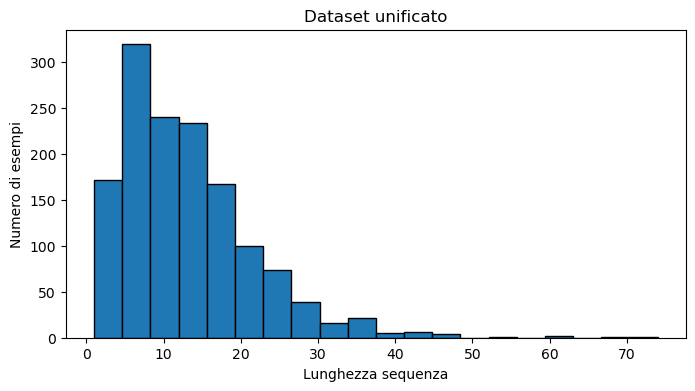

In [72]:
plot_sequence_length_distribution(X_train_seq, "Dataset unificato")

La maggior parte delle recensioni di entrambi i domini hanno una lunghezza inferiore a 30 parole, per tale motivo si è deciso di configurare MAX_LEN = 30, in modo da evitare l'inserimento di troppi token di padding, a costo di un eventuale troncamento di alcune recensioni di lunghezza superiore.

Viene quindi applicato il padding (o un troncamento) per riportare le sequenze di token in input alla lunghezza MAX_LEN.

In [73]:
MAX_LEN = 30

# Inserisce eventualmente del padding per fare in modo che tutte le sequenze in input siano lunghe MAX_LEN.
# In questo caso viene aggiunto padding alla fine di ogni frase, o vengono rimossi i termini alla fine di ogni frase per raggiungere lunghezza = MAXLEN.
X_train_pad_imdb = pad_sequences(X_train_seq_imdb, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad_imdb   = pad_sequences(X_val_seq_imdb, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad_imdb  = pad_sequences(X_test_seq_imdb, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_pad_yelp = pad_sequences(X_train_seq_yelp, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad_yelp   = pad_sequences(X_val_seq_yelp, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad_yelp  = pad_sequences(X_test_seq_yelp, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

Costruiamo un modello che viene addestrato e valutato su ciascuno dei due domini separatamente e sul dataset unificato. Poichè i due domini risultano simili (si tratta comunque di recensioni con lunghezze e un linguaggio simile), lo stesso modello basato sul LSTM verrà applicato ai diversi dataset costruiti (lo stesso approccio viene utilizzato anche per i modelli successivi).
<br>
Dopo diversi esperimenti condotti, la rete migliore risulta essere non troppo deep, costituita da un livello iniziale di embedding, appresi durante il training, un singolo livello basato su celle LSTM, e una head della rete che completa la classificazione, caratterizzata come una rete completamente connessa costituita da due livelli, di cui un primo livello con 32 unità e un livello di output con una singola unità (che usa la sigmoid come funzione di attivazione) per produrre la probabilità di appartenenza ad una delle due classi possibili.
<br>
La dimensione degli embedding è stata configurata in modo da non essere di dimensioni troppo ridotte, al fine di permettere alla rete di avere una capacità espressiva sufficiente e estrarre adeguatamente la semantica dai token in input. Al tempo stesso si è scelto di non utilizzare una dimensione eccessiva, data la dimensione limitata del vocabolario costruito a partire dal training set, e per evitare di favorire un rischio di overfitting avendo un maggior numero di parametri per questo livello (oltre che un costo computazionale maggiore per il training). A partire da queste considerazioni, una scelta ottimale è risultata essere EMBED_DIM = 128.
<br>
La dimensione del dataset ristretta e la semplicità del task di classificazione binaria, hanno favorito la scelta di una rete non troppo profonda, per evitare nuovamente rischio di overfitting e un training instabile. Anche la larghezza contenuta del singolo livello LSTM si riconduce a ragioni analoghe, ed inoltre un numero maggiore di unità non è risultato vantaggioso nel miglioramento delle performance.
<br>
La rete completamente connessa usata come head del classificatore, che riprende un architettura spesso usata nei task di text classification, permette di trasformare non linearmente la rappresentazione prodotta dal livello LSTM a partire dagli embedding di input, permettendo di combinare tra loro eventuali feature estratte da questo livello.
<br>
Un primo tentativo di applicazione del modello senza livelli di Dropout ha prodotto un risultato che tendeva ad andare in overfitting rapidamente, producendo un accuratezza quasi del 100% sul training set, e di molto inferiore sul validation set. Tale problematica è stata mitigata inserendo dei livelli di dropout, con una probabilità di dropout piuttosto contenuta (0.2%).

In [74]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(MAX_LEN,)),
        tf.keras.layers.Embedding(vocab_size, EMBED_DIM),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

Addestriamo e valutiamo il modello sul dataset imdb.

In [75]:
model_imdb = build_model()

model_imdb.summary()

I0000 00:00:1771515735.364125   11580 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4065 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 128)        │       446,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 498,497 (1.90 MB)

 Trainable params: 498,497 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

Sempre al fine di limitare il rischio di overfitting, viene utilizzato nel training di questo modello, così come per i modelli successivi, l'early stopping, in modo da interrompere il training quando non si osservano più miglioramenti significativi sulla loss di validazione.

In [76]:
history_imdb = model_imdb.fit(
    X_train_pad_imdb,
    y_train_imdb,
    validation_data=(X_val_pad_imdb, y_val_imdb),
    epochs=30,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30


2026-02-19 16:43:19.946557: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5057 - loss: 0.6945 - val_accuracy: 0.4867 - val_loss: 0.6939
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5329 - loss: 0.6903 - val_accuracy: 0.5600 - val_loss: 0.6931
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6014 - loss: 0.6614 - val_accuracy: 0.6333 - val_loss: 0.6318
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8814 - loss: 0.3585 - val_accuracy: 0.7533 - val_loss: 0.5412
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9571 - loss: 0.1646 - val_accuracy: 0.7467 - val_loss: 0.7321
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9514 - loss: 0.1468 - val_accuracy: 0.7333 - val_loss: 0.8855
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9857 - loss: 0.0785 - val_accuracy: 0.7800 - val_loss: 1.0116
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9843 - loss: 0.0725 - val_accuracy: 0.7867 - val_loss: 0.734

Tramite questa funzione è possibile mostrare graficamente l'andamento dell'accuratezza e della loss sul training set e sul validation set durante le epoche di training.

In [77]:
def plot_graphs(history,string, title):
    plt.title(title)
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel('epochs')
    plt.ylabel(string)
    plt.legend([string,'val_'+string])
    plt.show()

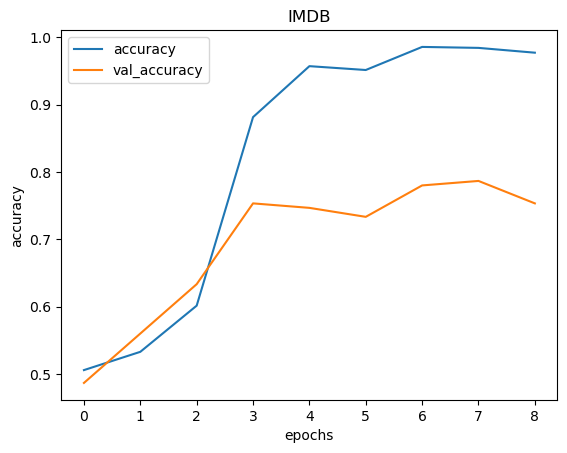

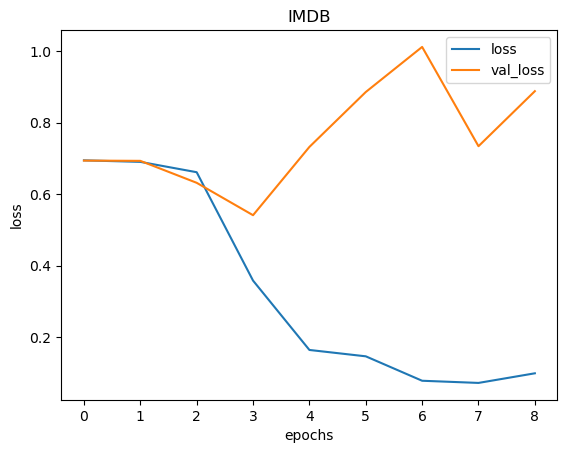

In [78]:
plot_graphs(history_imdb,'accuracy', 'IMDB')
plot_graphs(history_imdb,'loss', 'IMDB')

In [79]:
def evaluate_classifier(model, X_test, y_test, threshold=0.5):
    # Predizioni probabilistiche
    y_pred_prob = model.predict(X_test)

    # Conversione in classi
    y_pred = (y_pred_prob > threshold).astype(int)

    # Metriche
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"Accuracy: {acc:.3f}")
    print(f"F1 score: {f1:.3f}")

    return acc, f1

In [80]:
print("IMDB")
evaluate_classifier(model_imdb, X_test_pad_imdb, y_test_imdb)

IMDB
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Accuracy: 0.827
F1 score: 0.827


(0.8266666666666667, 0.8266358463726885)

Ora si considera il dataset yelp.

In [81]:
model_yelp = build_model()

In [82]:
history_yelp = model_yelp.fit(
    X_train_pad_yelp,
    y_train_yelp,
    validation_data=(X_val_pad_yelp, y_val_yelp),
    epochs=30,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4871 - loss: 0.6941 - val_accuracy: 0.5133 - val_loss: 0.6928
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5486 - loss: 0.6879 - val_accuracy: 0.6067 - val_loss: 0.6718
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7957 - loss: 0.5061 - val_accuracy: 0.7067 - val_loss: 0.5967
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9386 - loss: 0.2129 - val_accuracy: 0.7467 - val_loss: 0.6628
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9686 - loss: 0.1205 - val_accuracy: 0.7800 - val_loss: 0.7665
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9700 - loss: 0.1173 - val_accuracy: 0.7667 - val_loss: 1.0129
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9629 - loss: 0.1523 - val_accuracy: 0.7800 - val_loss: 0.9238
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9829 - loss: 0.0818 - val_accuracy: 0.7800 - va

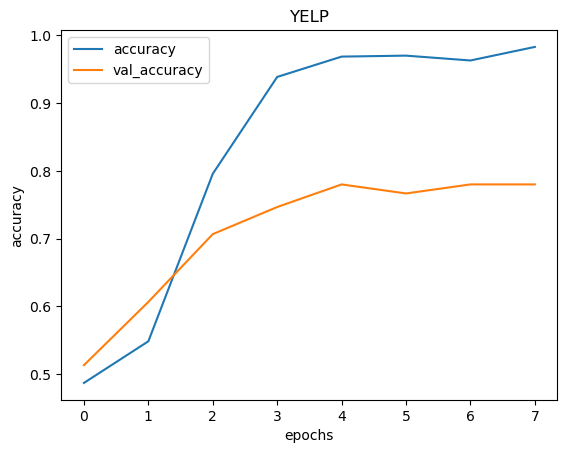

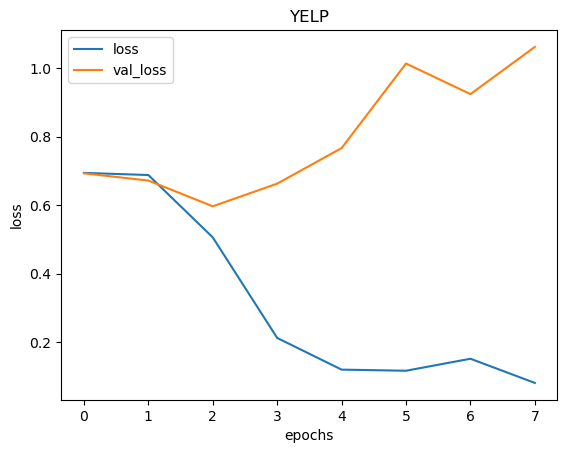

In [83]:
plot_graphs(history_yelp,'accuracy', 'YELP')
plot_graphs(history_yelp,'loss', 'YELP')

In [84]:
print("YELP")
evaluate_classifier(model_yelp, X_test_pad_yelp, y_test_yelp)

YELP
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Accuracy: 0.767
F1 score: 0.766


(0.7666666666666667, 0.7664071190211346)

Addestriamo e valutiamo sul dataset unificato.

In [105]:
model = build_model()

In [106]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=30,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5079 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5457 - loss: 0.6912 - val_accuracy: 0.5100 - val_loss: 0.6896
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7436 - loss: 0.5650 - val_accuracy: 0.7667 - val_loss: 0.5010
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9143 - loss: 0.2528 - val_accuracy: 0.8100 - val_loss: 0.4555
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9579 - loss: 0.1402 - val_accuracy: 0.7867 - val_loss: 0.5768
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9721 - loss: 0.1054 - val_accuracy: 0.7700 - val_loss: 0.6131
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9729 - loss: 0.1031 - val_accuracy: 0.8100 - val_loss: 0.6948
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9871 - loss: 0.0437 - val_accuracy: 0.7867 - val_lo

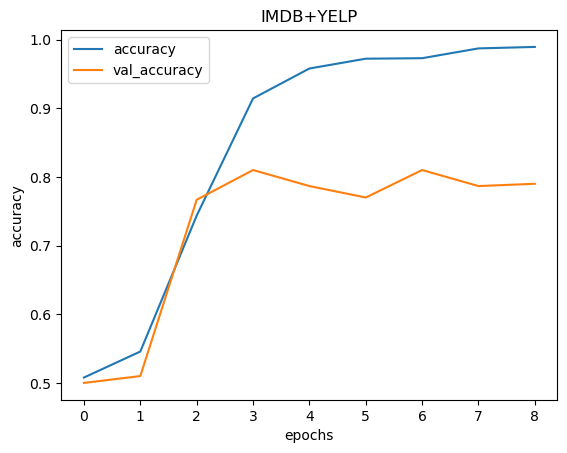

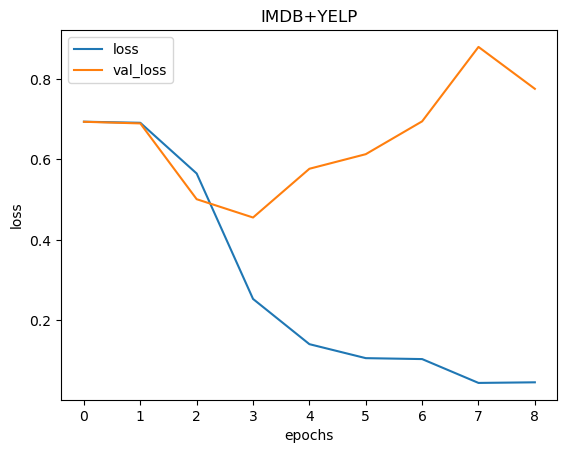

In [107]:
plot_graphs(history,'accuracy', 'IMDB+YELP' )
plot_graphs(history,'loss', 'IMDB+YELP')

In [108]:
print("IMDB+YELP")
evaluate_classifier(model, X_test_pad, y_test)

IMDB+YELP
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Accuracy: 0.770
F1 score: 0.768


(0.77, 0.767830505052771)

In tutti e tre i casi si ottengono prestazioni simili (o peggiori) di quelle ottenute per i modelli baseline. Questo comportamento può essere ricondotto alla scarsa quantità di dati a disposizione, che non permettono alla rete di individuare adeguatamente pattern all'interno dei dati in modo da acquisire capacità di generalizzazione sufficienti. La rete tende quindi ad andare in overfitting, nonostante i vari accorgimenti che sono stati portati avanti. Inoltre non è in grado di apprendere dai pochi dati a disposizione degli embedding che siano significativi al fine di risolvere il task di sentiment analysis. I modelli baseline come Naive Bayes e la regressione logistica riescono invece a sfruttare la presenza di termini fortemente polarizzati all'interno delle frasi (parole come "terrible", "good"...) così da indirizzare la classificazione verso risultati migliori.

Anche in questo caso si analizza se il training su IMDB+YELP favorisce una migliore accuratezza sul dominio yelp, che invece presenta scarsi risultati nel caso di training sul dominio individuale.

In [109]:
import numpy as np
import pandas as pd

def print_nn_domain_accuracy(model, X_input, y_true, X_original_text, data_df, threshold=0.5):
    # Ottiene le probabilità dal modello
    y_pred_prob = model.predict(X_input, verbose=0)
    
    y_pred = (np.squeeze(y_pred_prob) > threshold).astype(int)
    
    if isinstance(y_true, pd.Series):
        y_true = y_true.values
        
    domains = data_df.loc[X_original_text.index, 'domain'].values
    
    analysis_df = pd.DataFrame({
        'Is_Correct': y_true == y_pred,
        'Domain': domains
    })
    
    # Calcola e stampa le statistiche
    domain_stats = analysis_df.groupby('Domain')['Is_Correct'].agg(['sum', 'count', 'mean'])
    
    print(f"\nAccuratezza per dominio:")
    for domain in domain_stats.index:
        num_correct = int(domain_stats.loc[domain, 'sum'])
        num_total = int(domain_stats.loc[domain, 'count'])
        accuracy_pct = domain_stats.loc[domain, 'mean'] * 100
        
        print(f"Dominio {domain.upper()}: {num_correct}/{num_total} corretti ({accuracy_pct:.2f}%)")
    print("\n")

In [110]:
print_nn_domain_accuracy(
    model=model, 
    X_input=X_test_pad,       
    y_true=y_test, 
    X_original_text=X_test_text,
    data_df=data
)


Accuratezza per dominio:
Dominio IMDB: 109/150 corretti (72.67%)
Dominio YELP: 122/150 corretti (81.33%)




Come osservato per i modelli della baseline, per ragioni analoghe anche il modello basato su LSTM evidenzia un miglioramento delle prestazioni notevole sul dominio yelp se addestrato su entrambi i domini congiuntamente.

In [111]:
log_neural_performance("LSTM", 
                       model_imdb, X_test_pad_imdb, y_test_imdb,
                       model_yelp, X_test_pad_yelp, y_test_yelp,
                       model, X_test_pad, y_test)

Risultati per 'LSTM' salvati su CSV.


## LSTM + pre-trained embedding

Una delle strategie per ridurre il numero di parametri della rete, e mitigare il problema dei pochi dati a disposizione per il training, è quella di utilizzare degli embedding pre-addestrati, piuttosto che apprendere gli embedding durante il training. In particolare vengono utilizzati gli embedding GloVe, che rappresentano le parole in uno spazio vettoriale in cui termini semanticamente simili risultano geometricamente vicini.
<br>
Questi embeddings pre-addestrati vengono forniti in diverse dimensioni possibili. Tramite diversi tentativi è risultato che la rete trae maggiore vantaggio da una dimensionalità maggiore degli embedding pre-trained, e per tale motivo ogni parola viene quindi codificata con un vettore di dimensione pari a 300 elementi.
<br>
Si procede quindi a caricare gli embeddings partendo da un file testuale che li contiene.

In [112]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [113]:
# Costruisce un dizionario in cui ad ogni parola è associato il vettore di 300 elementi come indicato nel file degli embeddings
embedding_vector = {}
f = open('glove.6B/glove.6B.300d.txt')
for line in tqdm(f):
    value = line.split(' ')
    word = value[0]
    coef = np.array(value[1:],dtype = 'float32')
    embedding_vector[word] = coef

400000it [00:12, 32643.46it/s]


Con questa cella vengono costruite le matrici di embedding pre-trained da utilizzare per ciascun modello addestrato e valutato su un diverso dominio.

In [114]:
embedding_matrix_imdb = np.zeros((vocab_size_imdb,300))
for word,i in tqdm(tokenizer_imdb.word_index.items()):
    embedding_value = embedding_vector.get(word)
    if embedding_value is not None:
        embedding_matrix_imdb[i] = embedding_value

embedding_matrix_yelp = np.zeros((vocab_size_yelp,300))
for word,i in tqdm(tokenizer_yelp.word_index.items()):
    embedding_value = embedding_vector.get(word)
    if embedding_value is not None:
        embedding_matrix_yelp[i] = embedding_value

embedding_matrix = np.zeros((vocab_size,300))
for word,i in tqdm(tokenizer.word_index.items()):
    embedding_value = embedding_vector.get(word)
    if embedding_value is not None:
        embedding_matrix[i] = embedding_value

100%|███████████████████████████████████████████████████████████████████████████| 3491/3491 [00:00<00:00, 637870.41it/s]


Viene utilizzato un modello analogo alla sezione precedente (LSTM), ma si utilizzano, come già indicato, embeddings pre-trained piuttosto che appresi durante il training, e inolte non risulta vantaggioso da diversi tentativi condotti l'utilizzo dei livelli di dropout. Questo è dovuto al fatto che non c'è rischio di overfitting sugli embeddings, poichè i loro pesi non vengono aggiornati durante il training (come indicato da trainable=False nei parametri del livello), ed inoltre i livelli di dropout successivi potrebbero peggiorare la qualità della rappresentazione semantica già piuttosto ottimale e manipolata dai livelli della rete. Inoltre il numero ristretto di parametri, dovuto proprio all'uso degli embeddings pre-trained, fa sì che la rete non necessiti di una regolarizzazione particolare.

In [115]:
def build_LSTM_pretrained(vocab_size, embeddings):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(MAX_LEN,)),
        tf.keras.layers.Embedding(vocab_size,300,weights = [embeddings],input_length=MAX_LEN,trainable = False),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

Addestriamo e valutiamo il modello sul dominio imdb.

In [116]:
model_imdb = build_LSTM_pretrained(vocab_size_imdb, embedding_matrix_imdb)

model_imdb.summary()

/home/matteo/miniforge3/envs/ML25/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 30, 300)        │       747,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 842,553 (3.21 MB)

 Trainable params: 95,553 (373.25 KB)

 Non-trainable params: 747,000 (2.85 MB)

In [117]:
history_imdb = model_imdb.fit(
    X_train_pad_imdb,
    y_train_imdb,
    validation_data=(X_val_pad_imdb, y_val_imdb),
    epochs=30,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5186 - loss: 0.6916 - val_accuracy: 0.5200 - val_loss: 0.6966
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5586 - loss: 0.6786 - val_accuracy: 0.6800 - val_loss: 0.6946
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6886 - loss: 0.6064 - val_accuracy: 0.7200 - val_loss: 0.5395
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8200 - loss: 0.4149 - val_accuracy: 0.8200 - val_loss: 0.4505
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8671 - loss: 0.3344 - val_accuracy: 0.7733 - val_loss: 0.4904
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9014 - loss: 0.2643 - val_accuracy: 0.7600 - val_loss: 0.4761
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9214 - loss: 0.2439 - val_accuracy: 0.7333 - val_loss: 0.6708


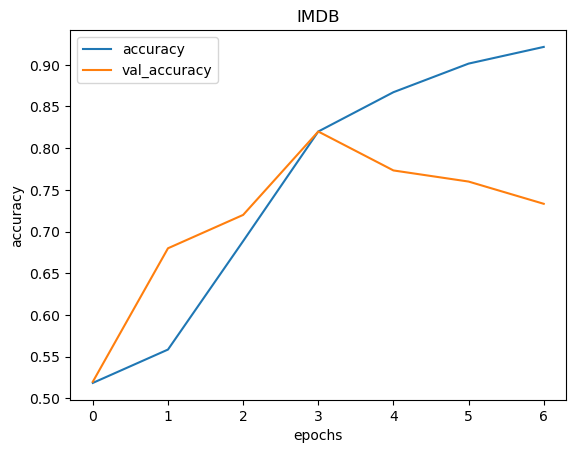

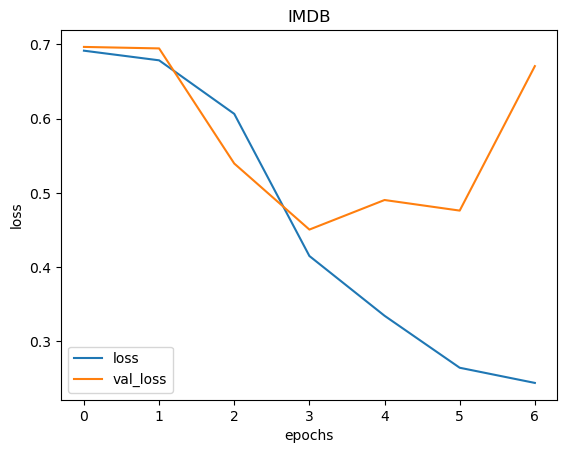

In [118]:
plot_graphs(history_imdb,'accuracy', 'IMDB')
plot_graphs(history_imdb,'loss', 'IMDB')

In [119]:
print("IMDB")
evaluate_classifier(model_imdb, X_test_pad_imdb, y_test_imdb)

IMDB
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Accuracy: 0.853
F1 score: 0.853


(0.8533333333333334, 0.8529149581030486)

Addestriamo e valutiamo sul dominio yelp.

In [129]:
model_yelp = build_LSTM_pretrained(vocab_size_yelp, embedding_matrix_yelp)

/home/matteo/miniforge3/envs/ML25/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [130]:
history_yelp = model_yelp.fit(
    X_train_pad_yelp,
    y_train_yelp,
    validation_data=(X_val_pad_yelp, y_val_yelp),
    epochs=30,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5557 - loss: 0.6886 - val_accuracy: 0.5867 - val_loss: 0.6798
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6771 - loss: 0.6131 - val_accuracy: 0.7000 - val_loss: 0.5623
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8157 - loss: 0.4540 - val_accuracy: 0.7400 - val_loss: 0.5097
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8643 - loss: 0.3526 - val_accuracy: 0.7467 - val_loss: 0.5295
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8857 - loss: 0.3094 - val_accuracy: 0.8000 - val_loss: 0.4728
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9257 - loss: 0.2217 - val_accuracy: 0.7867 - val_loss: 0.5413
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9314 - loss: 0.2138 - val_accuracy: 0.7933 - val_loss: 0.5705
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9343 - loss: 0.2101 - val_accuracy: 0.8067 - val_l

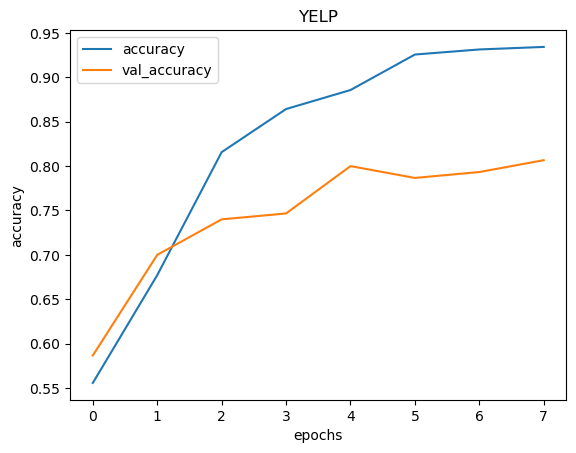

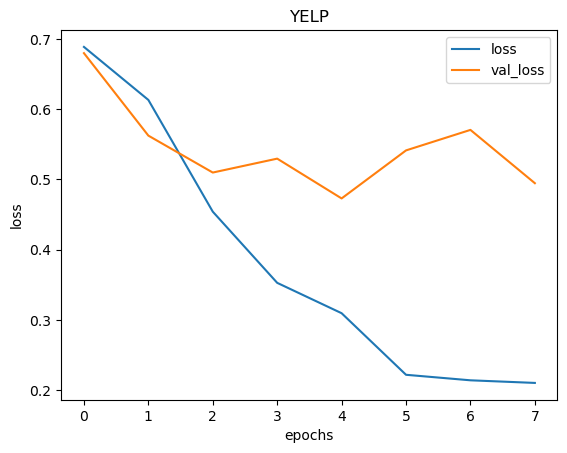

In [131]:
plot_graphs(history_yelp,'accuracy', 'YELP')
plot_graphs(history_yelp,'loss', 'YELP')

In [132]:
print("YELP")
evaluate_classifier(model_yelp, X_test_pad_yelp, y_test_yelp)

YELP
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Accuracy: 0.807
F1 score: 0.807


(0.8066666666666666, 0.806658073692164)

Addestriamo e valutiamo il modello sul dataset unificato.

In [133]:
model = build_LSTM_pretrained(vocab_size, embedding_matrix)

/home/matteo/miniforge3/envs/ML25/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [134]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=30,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5864 - loss: 0.6783 - val_accuracy: 0.5667 - val_loss: 0.6909
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7536 - loss: 0.5342 - val_accuracy: 0.7767 - val_loss: 0.4739
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8457 - loss: 0.3762 - val_accuracy: 0.8133 - val_loss: 0.4697
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8764 - loss: 0.3122 - val_accuracy: 0.8400 - val_loss: 0.3913
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8986 - loss: 0.2590 - val_accuracy: 0.8267 - val_loss: 0.4117
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9200 - loss: 0.2239 - val_accuracy: 0.8467 - val_loss: 0.4172
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9386 - loss: 0.1819 - val_accuracy: 0.8433 - val_loss: 0.4433


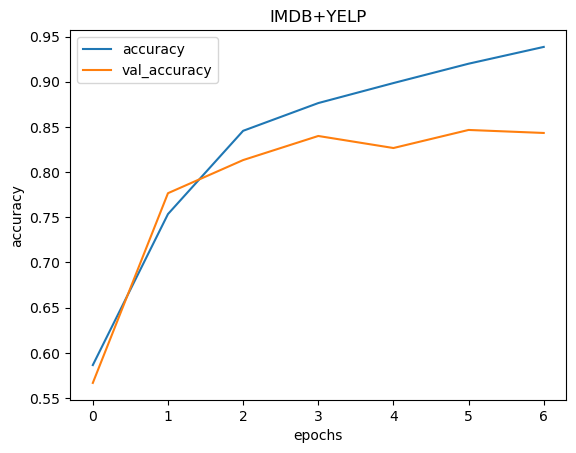

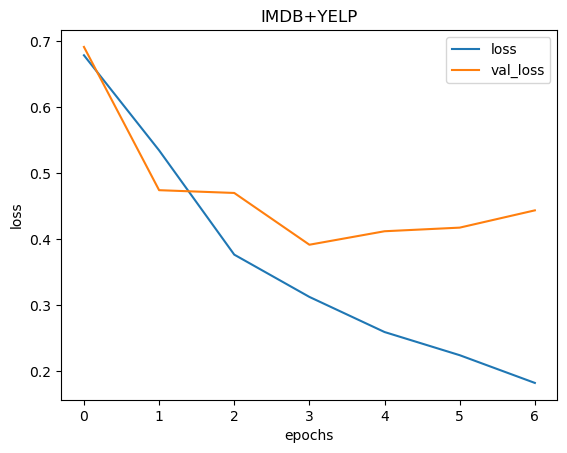

In [135]:
plot_graphs(history,'accuracy', 'IMDB+YELP')
plot_graphs(history,'loss', 'IMDB+YELP')

In [136]:
print("IMDB+YELP")
evaluate_classifier(model, X_test_pad, y_test)

IMDB+YELP
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Accuracy: 0.833
F1 score: 0.833


(0.8333333333333334, 0.8329695781925082)

In conclusione si osserva come l'utilizzo degli embeddings pre-trained permetta di migliorare le prestazioni ottenute dalla rete basata su LSTM. Infatti su tutti e due i domini, e sul dataset unificato, si evidenzia un miglioramento sia dell'accuratezza che del f1-score (in particolare un vantaggio notevole nell'uso degli embeddings-pretrained si ottiene sul dominio yelp, che presentava le prestazioni peggiori). Inoltre sia relativamente a imdb che al dataset unificato, questo modello raggiunge prestazioni migliori rispetto alla baseline (regressione logistica e Naive Bayes). Ciò può essere ricondotto alla capacità della rete LSTM di catturare la dinamica di sequenze di token in input e il loro ordine, piuttosto che doverle codificare in singoli vettori come accadeva nei modelli precedenti. Inoltre l'utilizzo degli embeddings GloVe permette alla rete di partire da una rappresentazione semantica dei termini già significativa per la risoluzione del task di text classification.

In [137]:
print_nn_domain_accuracy(
    model=model, 
    X_input=X_test_pad,       
    y_true=y_test, 
    X_original_text=X_test_text,
    data_df=data
)


Accuratezza per dominio:
Dominio IMDB: 124/150 corretti (82.67%)
Dominio YELP: 126/150 corretti (84.00%)




Anche in questo caso il training congiunto su entrambi i domini produce significativi miglioramenti sulla classificazione delle recensioni yelp nel test set.

In [138]:
log_neural_performance("LSTM+pretrained embeddings", 
                       model_imdb, X_test_pad_imdb, y_test_imdb,
                       model_yelp, X_test_pad_yelp, y_test_yelp,
                       model, X_test_pad, y_test)

Risultati per 'LSTM+pretrained embeddings' salvati su CSV.


## Transformer block (encoder-only BERT-like)

A questo punto viene applicato un altro modello adatto al processamento di dati sequenziali in input, ossia un modello basato sui transformers block. Differentemente dalla rete ricorrente, il transformer riceve in input l'intera sequenza di token in parallelo, e questo permette di trarne vantaggio dal punto di vista del tempo di training, in particolare sfruttando un architettura hardware parallela. Tra le principali differenze di questa architettura rispetto alle reti precedenti si sottolinea la capacità dei transformer blocks di produrre degli embedding contestuali, che quindi tengono conto del contesto (ossia delle altre parole della sequenza) in cui è collocato ogni token ricevuto in input. Questo permette al modello di estrarre una rappresentazione semantica diversa di uno stesso token a seconda della sequenza in cui compare, capacità non presente invece nelle reti riccorrenti che utilizzano esclusivamente degli embeddings, appresi o pre-trained, statici. Si vuole quindi analizzare se tale meccanismo permette di acquisire delle capacità di generalizzazione migliori rispetto alle reti LSTM presentate in precedenza.
<br>
Si costruisce quindi il blocco fondamentale di questa architettura, costituito da multi-head self attention (che permette di estrarre l'informazione di contesto), rete feed-forward, connessioni residuali, livelli di normalizzazione e di dropout.

In [139]:
from tensorflow.keras import layers

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads,
                                             key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

Si definisce quindi l'archittetura di questo modello basato su transformers block.
<br>
In input viene ricevuta la sequenza di indici di token, a cui vengono associati degli embedding iniziali (non ancora contestuali). In maniera analoga alla rete LSTM precedente, anche qui si trae vantaggio dall'uso di embedding iniziali pre-trained, piuttosto che appresi durante il training. La differenza principale però risiede nel fatto che in questo caso il livello di embedding è addestrabile. L'idea proposta quindi è che il modello possa partire da pesi iniziali per gli embedddings non casuali ma prodotti tramite GloVe (quindi embeddings di 300 elementi che già codificano relazioni semantiche statiche tra termini in uno spazio vettoriale), e realizzare un aggiornamento di questi pesi che permetta di adattare gli embeddings allo specifico task di sentiment analsyis che il modello vuole risolvere. I risultati ottenuti in questo modo possono infatti essere migliori rispetto al caso in cui gli embeddings iniziali sono congelati e quindi non ottimali per la risoluzione del task, dato che l'attenzione lavora su rappresentazioni iniziali poco significative. Inoltre questo permette di convergere più velocemente a degli embeddings iniziali ottimali rispetto al caso di embeddings appresi a partire da pesi iniziali casuali.
<br>
Questi token embedding vengono quindi sommati a degli embedding posizionali, che infatti codificano la posizione dei token all'interno della sequenza, informazione che può essere significativa ai fini della risoluzione del task (se il termine "not" precede "good" nella sequenza, questo può essere significativo al fine di individuare un sentimento negativo). In questo caso si è scelto di utilizzare degli embedding posizionali appresi durante il training, che seppur portano ad un aumento del numero di parametri del modello, possono essere vantaggiosi specialmente nel caso di sequenze in input della medesima lunghezza, come quelle ricevute dal modello costruito grazie all'utilizzo del padding presentato in precedenza.
<br>
A seguire il livello degli embeddings è presente una catena di blocchi transformer, che producono incrementalmente degli embeddings contestuali sempre più ottimali per la risoluzione del task considerato. Da diversi tentativi condotti è risultato com un singolo blocco non fosse sufficiente per estrarre adeguatamente delle informazioni di contesto, mentre un numero eccessivo di blocchi viceversa producesse un modello troppo complesso che tendeva rapidamente ad andare in overfitting e generalizzare male su nuove sequenze in input. Si è quindi deciso di utilizzare una catena di 3 blocchi transormer successivi, che è risultata ottimale data la dimensionalità degli embeddings considerati, la lunghezza delle sequenza, la non eccessiva difficoltà del task considerato e la dimensione ridotta del dataset di training a disposizione, e anche un corretto trade-off per evitare un aumento eccessivo nel numero di parametri che avrebbe prodotto un costo computazionale troppo elevato per il training.
<br>
Per ogni blocco si è scelto di utilizzare 4 attention heads. Ogni head è in grado di catturare diverse relazioni contestuali tra gli embeddings di input. Un numero inferiore di heads avrebbe comportato una capacità insufficiente del modello di catturare diverse relazioni linguistiche tra token, mentre un numero maggiore avrebbe prodotto un aumento di parametri, e quindi un aumento del costo computazionale, senza produrre un reale beneficio dato il dataset di dimensioni piuttosto ridotte. Quindi l'utilizzo di 4 heads permette al modello di apprendere differenti relazioni contestuali mantenendo contenuta la complessità del modello.
<br>
In maniera analoga sono state mantenute contenute le dimensioni della rete feed-forward, di 128 unità. Questa dimensione è ragionevole considerata la dimensione degli embeddings processati dai blocchi transformer, permettendo al modello di avere sufficiente capacità espressiva senza produrre un rischio elevato di overfitting.
<br>
La catena di blocchi transformer è seguita da un livello di Global Average Pooling, che permette di produrre, a partire da una sequenza di rappresentazioni contestuali prodotte dai blocchi precedenti per ogni token in input, un unico vettore che rappresenta l'intera frase (facendo la media tra i vettori della sequenza). Questo permette di ottenere una rappresentazione vettoriale dell'intera frase, riducendo i parametri rispetto all'utilizzo di una linearizzazione della sequenza (tramite livello flatten). Questo approccio di fatto produce risultati simili rispetto all'utilizzo del token speciale [CLS] che rappresenta una sintesi dell'intera sequenza in input, strategia spesso utilizzata nei modelli di tipo BERT.
<br>
In maniera analoga a quanto fatto per la rete LSTM, la head del classificatore è rappresentata da una rete completamente connessa con 32 unità e un livello di output con una singola unità (con la sigmoid) che produce la probabilità di appartenenza alla classe positiva.

In [140]:
EMBED_DIM = 300

def build_transformer(vocab_size, embeddings):
    inputs = layers.Input(shape=(MAX_LEN,))
    
    # Token embedding (GloVe)
    token_embeddings = layers.Embedding(
            input_dim=vocab_size,
            output_dim=EMBED_DIM,
            weights=[embeddings],
            input_length=MAX_LEN,
            trainable=True
    )(inputs)
    
    # Positional embedding appreso
    positions = tf.range(start=0, limit=MAX_LEN, delta=1)
    position_embeddings = layers.Embedding(
            input_dim=MAX_LEN,
            output_dim=EMBED_DIM
    )(positions)
    
    # Somma token + posizione
    x = token_embeddings + position_embeddings
    
    x = TransformerBlock(embed_dim=EMBED_DIM,
                         num_heads=4,
                         ff_dim=128)(x)
    
    x = TransformerBlock(embed_dim=EMBED_DIM,
                         num_heads=4,
                         ff_dim=128)(x)
    
    x = TransformerBlock(embed_dim=EMBED_DIM,
                         num_heads=4,
                         ff_dim=128)(x)
    
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

Addestriamo e valutiamo il modello sul dataset imdb.

In [153]:
model_imdb = build_transformer(vocab_size_imdb, embedding_matrix_imdb)

model_imdb.summary()

Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_21 (Embedding)        │ (None, 30, 300)        │       747,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_4 (Add)                     │ (None, 30, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_12            │ (None, 30, 300)        │     1,522,328 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_13            │ (None, 30, 300)        │     1,522,328 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_14            │ (None, 30, 300)        │     1,522,328 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 300)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 32)             │         9,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,323,649 (20.31 MB)

 Trainable params: 5,323,649 (20.31 MB)

 Non-trainable params: 0 (0.00 B)

In [154]:
history_imdb = model_imdb.fit(
    X_train_pad_imdb,
    y_train_imdb,
    validation_data=(X_val_pad_imdb, y_val_imdb),
    epochs=30,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 473ms/step - accuracy: 0.4843 - loss: 0.8819 - val_accuracy: 0.5000 - val_loss: 0.7526
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4771 - loss: 0.7186 - val_accuracy: 0.5000 - val_loss: 0.6913
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5114 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.6958
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7414 - loss: 0.5471 - val_accuracy: 0.8133 - val_loss: 0.4475
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8743 - loss: 0.3379 - val_accuracy: 0.8400 - val_loss: 0.4521
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9186 - loss: 0.2239 - val_accuracy: 0.8333 - val_loss: 0.4652
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9614 - loss: 0.1214 - val_accuracy: 0.8000 - val_loss: 0.8914
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9700 - loss: 0.1084 - val_accuracy: 0.8067 -

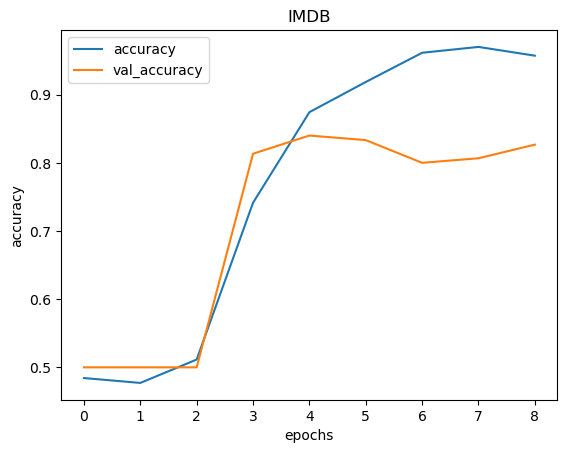

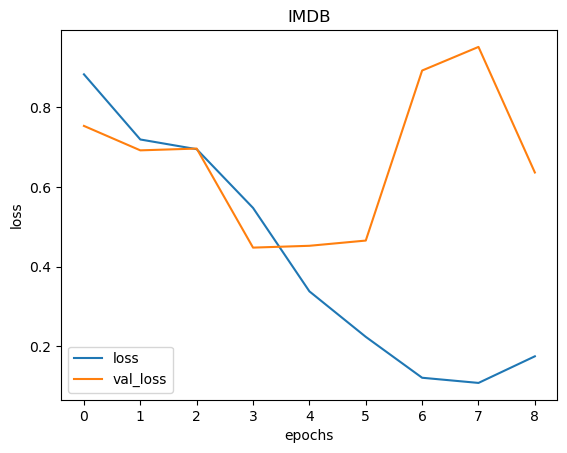

In [155]:
plot_graphs(history_imdb,'accuracy', 'IMDB')
plot_graphs(history_imdb,'loss', 'IMDB')

In [156]:
print("IMDB")
evaluate_classifier(model_imdb, X_test_pad_imdb, y_test_imdb)

IMDB
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step
Accuracy: 0.833
F1 score: 0.833


(0.8333333333333334, 0.8332666399893291)

Addestriamo e valutiamo il modello sul dominio yelp.

In [161]:
model_yelp = build_transformer(vocab_size_yelp, embedding_matrix_yelp)

/home/matteo/miniforge3/envs/ML25/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [162]:
history_yelp = model_yelp.fit(
    X_train_pad_yelp,
    y_train_yelp,
    validation_data=(X_val_pad_yelp, y_val_yelp),
    epochs=30,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 479ms/step - accuracy: 0.4657 - loss: 0.8173 - val_accuracy: 0.5000 - val_loss: 0.7151
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5186 - loss: 0.7060 - val_accuracy: 0.5000 - val_loss: 0.6892
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6200 - loss: 0.6520 - val_accuracy: 0.6467 - val_loss: 0.7523
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8500 - loss: 0.3907 - val_accuracy: 0.8000 - val_loss: 0.5386
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8900 - loss: 0.3562 - val_accuracy: 0.8067 - val_loss: 0.6196
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9200 - loss: 0.2574 - val_accuracy: 0.8200 - val_loss: 0.6127
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9357 - loss: 0.2076 - val_accuracy: 0.8133 - val_loss: 0.5644
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9371 - loss: 0.2182 - val_accuracy: 0.7867 -

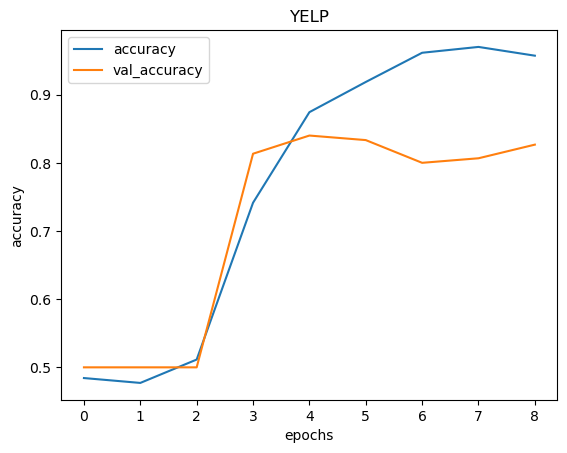

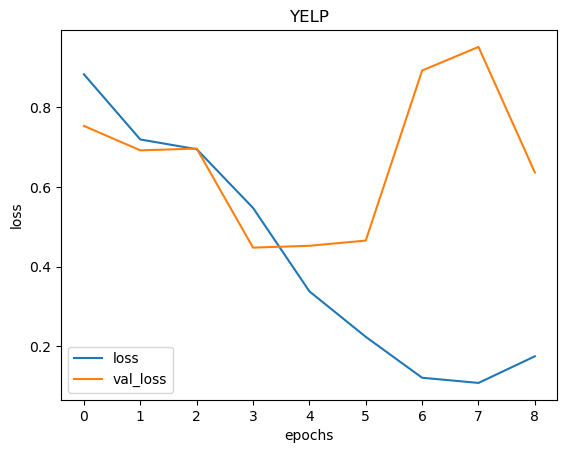

In [163]:
plot_graphs(history_imdb,'accuracy', 'YELP')
plot_graphs(history_imdb,'loss', 'YELP')

In [164]:
print("YELP")
evaluate_classifier(model_yelp, X_test_pad_yelp, y_test_yelp)

YELP
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step
Accuracy: 0.820
F1 score: 0.818


(0.82, 0.8176579172482104)

Addestriamo e valutiamo il modello sul dataset unificato.

In [194]:
model = build_transformer(vocab_size, embedding_matrix)

/home/matteo/miniforge3/envs/ML25/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [195]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=30,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 271ms/step - accuracy: 0.5943 - loss: 0.6973 - val_accuracy: 0.7867 - val_loss: 0.4458
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8129 - loss: 0.4136 - val_accuracy: 0.7500 - val_loss: 0.4865
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8900 - loss: 0.2761 - val_accuracy: 0.8200 - val_loss: 0.4633
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9186 - loss: 0.2111 - val_accuracy: 0.8500 - val_loss: 0.3849
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9350 - loss: 0.1687 - val_accuracy: 0.8400 - val_loss: 0.4999
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9464 - loss: 0.1573 - val_accuracy: 0.7833 - val_loss: 0.4989
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9371 - loss: 0.2180 - val_accuracy: 0.8000 - val_loss: 0.6452
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9436 - loss: 0.1628 - val_accuracy: 0.8167 -

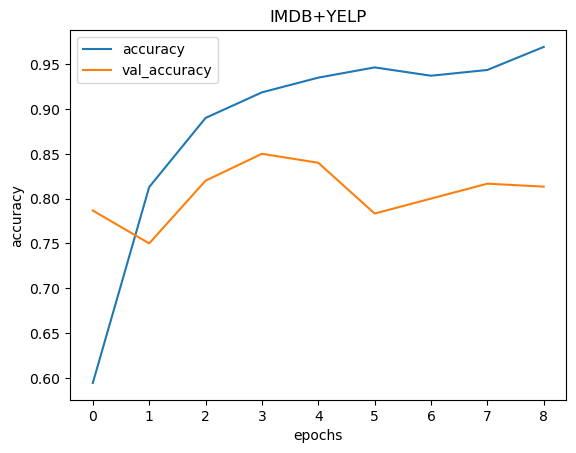

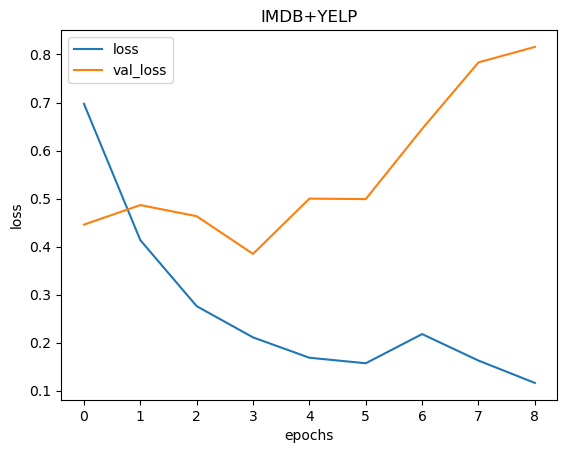

In [196]:
plot_graphs(history,'accuracy', 'IMDB+YELP')
plot_graphs(history,'loss', 'IMDB+YELP')

In [197]:
print("IMDB+YELP")
evaluate_classifier(model, X_test_pad, y_test)

IMDB+YELP
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step
Accuracy: 0.840
F1 score: 0.840


(0.84, 0.8396507950648078)

Con questo modello si ottengono prestazioni leggermente migliori rispetto alla rete LSTM con embeddings pre-trained (su yelp e dataset unificato, simili su imdb). Si evince che l'architettura basata su blocchi transformers trae vantaggio da un training set di dimensione maggiore, quale quello che si ottiene unendo i domini imdb e yelp, avendo anche la possibilità di osservare esempi maggiormente diversificati tra di loro, che spaziano su ambiti diversi. Questa maggior disponibilità di esempi permette infatti al modello di configurare i pesi dei livelli di attention in modo da produrre degli embeddings contestuali migliori per l'indentificazione del sentimento espresso dalla frase in input. Inoltre si sottolinea come gli embeddings contestuali permettano al modello di catturare pattern e relazioni semantiche tra tutti i token della sequenza che gli embeddings statici utilizzati nella rete LSTM non sono in grado di indentificare. Infine i transformers traggono vantaggio dal processamento in parallelo di tutti i token in input, che rimuove completamente la possibilità di perdita di informazione che, seppur in maniera minore alle reti ricorrenti tradizionali, la rete LSTM presenta poichè processa sequenzialmente i token in input.
<br>
Sebbene il processamento in parallelo velocizzi di molto il training quando sfrutta una architettura hardware parallela, il maggior numero di parametri di questo modello transformer implica un tempo maggiore per realizzare il training rispetto alla rete LSTM della sezione precedente. Ciò nonostante il costo computazionale è comunque contenuto (training di pochi minuti anche su una gpu poco potente), data la dimensione ridotta del dataset di training.

In [198]:
print_nn_domain_accuracy(
    model=model, 
    X_input=X_test_pad,       
    y_true=y_test, 
    X_original_text=X_test_text,
    data_df=data
)


Accuratezza per dominio:
Dominio IMDB: 122/150 corretti (81.33%)
Dominio YELP: 130/150 corretti (86.67%)




Anche il modello basato su blocchi transformers tra vantaggio dal training sul dataset IMDB+YELP, relativamente alla classificazione delle recensioni yelp. Avere maggiori esempi di training a disposizione permette al modello di apprendere parametri che permettono di costruire embedding contestuali sempre più mirati a risolvere il task di sentiment analysis.

In [199]:
log_neural_performance("Transformer", 
                       model_imdb, X_test_pad_imdb, y_test_imdb,
                       model_yelp, X_test_pad_yelp, y_test_yelp,
                       model, X_test_pad, y_test)

Risultati per 'Transformer' salvati su CSV.


## BERT + fine-tuning

Per cercare di risolvere la problematica relativa ai pochi dati di training a disposizione, una possibilità è quella di utilizzare un modello pre-addestrato su cui realizzare fine-tuning, in modo da ridurre notevolmente il numero di parametri da addestrare. In particolare proseguendo con l'idea presentata nella sezione precedente, si propone l'utilizzo di un modello basato su blocchi transformer, ossia BERT, architettura encoder-only spesso utilizzata per risolvere task di NLP, tra cui sentiment analysis.

In [201]:
import tensorflow_text as text
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras as keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from focal_loss import BinaryFocalLoss

Si procede ora a caricare il modello BERT pre-addestrato, indicato come encoder nella cella sottostante. Viene anche caricato il preprocessore, che esegue tutte le operazioni necessarie per trasformare una frase in un input numerico compatibile con l'encoder BERT. In particolare realizza operazioni di conversione del testo in lettere minuscole, tokenizzazione WordPiece, inserimento di token speciali [CLS] e [SEP], padding e troncamento alla lunghezza massima prevista (512 token) e costruzione dei tensori in input. L'encoder invece rappresenta l'effettivo modello BERT che legge i token, utilizza la self-attention e produce le rappresentazioni contestuali.
<br>
Sono disponibili diverse varianti di questo modello. Si è deciso di utilizzare il modello base di BERT, ossia addestrato su testi in inglese (en), con testo convertito completamente in minuscolo (uncased), e con un'architettura costitutita da 12 blocchi transformer (encoder), in cui ciascuno produce una rappresentazione di dimensione pari a 768, utilizzando 12 attention heads.
Come indicato dal parametro Trainable= False, i pesi dell'encoder sono congelati, e verranno addestrati solo i pesi del classificatore collocato sopra al modello BERT, seguendo la strategia del fine-tuning, che permette di ridurre notevolmente il numero di parametri da addestrare, permettendo di ottenere ottimi risultati mantenendo limitato il costo computazionale del training. L'idea infatti è quella di sfruttare la conoscenza del linguaggio naturale già presente in BERT preaddestrato in modo da costruire degli embedding contestuali migliori di quelli ottenibili con il modello basato su blocchi transformer presentato nella sezione precedente, che invece era limitato dalla scarsità dei dati di training a disposizione. Il training si limita quindi ai soli livelli completamente connessi collocati sopra a BERT, con l'obiettivo di risolvere il task di sentiment analysis, e quindi di estrarre il sentimento espresso dalle frasi, ma partendo da ottime rappresentazioni iniziali.

In [202]:
preprocessor = hub.KerasLayer("https://kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/en-uncased-preprocess/versions/3")
encoder = hub.KerasLayer("https://www.kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/en-uncased-l-12-h-768-a-12/versions/4", trainable=False)

Viene quindi costruito il modello, che prende in input le recensioni in formato testuale, le processa come indicato in precedenza, e produce tramite la parte di encoding una rappresentazione contestuale. In particolare considera l'embedding contestuale prodotto per il token CLS (indicato come pooled_output) che incapsula una rappresentazione dell'intera frase di input. Tale rappresentazione è fornita in input a una rete completamente connessa, costituita da tre livelli densi con 64 unità ciascuno. Infine un livello di output con una singola unità (con sigmoid) produce la probabilità di appartenenza ad una data classe.
La rete completamente connessa si adatta durante il training allo specifico task di sentiment analysis. Essendo un task non estremamente complesso, come risultato anche durante l'utilizzo dei modelli precedenti, una rete eccessivamente profonda porterebbe ad un rapido overfitting sui dati di training. Viceversa un singolo livello comporterebbe una capacità espressiva troppo ridotta della rete, impossibilitata ad estrarre adegutamente il sentimento a partire dalla rappresentazione prodotta da BERT. Per tale motivo, diversi tentativi condotti hanno portato a scegliere una rete costituita da 3 livelli, con un numero ristretto di unità (pari a 64), ottimale per risolvere il task prefissato, e permettendo di avere un costo computazionale di training ridotto dato il numero di parametri limitato (molto inferiore rispetto all'architettura basata su blocchi transformer completamente addestrata nella sezione precedente).

In [203]:
def build_bert_classifier():
    text_input = keras.layers.Input(shape=(), dtype=tf.string)

    # Preprocessa il testo con TF_HUB
    encoder_inputs = preprocessor(text_input)

    # BERT model
    outputs = encoder(encoder_inputs)

    pooled_output = outputs["pooled_output"]

    x = keras.layers.Dense(64, activation='relu', name="dense-1-64")(pooled_output)
    x = keras.layers.Dense(64, activation='relu', name="dense-2-64")(x)
    x = keras.layers.Dense(64, activation='relu', name="dense-3-64")(x)

    output = keras.layers.Dense(1, activation='sigmoid', name="output")(x)

    model = keras.Model(inputs=[text_input], outputs=[output])

    model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
    
    return model

Addestriamo e valutiamo sul dominio imdb.

In [209]:
model_imdb = build_bert_classifier()

In [210]:
model_imdb.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None,)]                    0         []                            
                                                                                                  
 keras_layer (KerasLayer)    {'input_type_ids': (None,    0         ['input_2[0][0]']             
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                            

In [211]:
from tf_keras.callbacks import EarlyStopping

history_imdb = model_imdb.fit(
    X_train_text_imdb, y_train_imdb,
    validation_data=(X_val_text_imdb, y_val_imdb),
    epochs=30,
    verbose=1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
)

Epoch 1/30
22/22 [==============================] - 17s 687ms/step - loss: 0.6814 - accuracy: 0.5657 - val_loss: 0.6884 - val_accuracy: 0.5667
Epoch 2/30
22/22 [==============================] - 14s 659ms/step - loss: 0.6579 - accuracy: 0.6329 - val_loss: 0.6836 - val_accuracy: 0.5667
Epoch 3/30
22/22 [==============================] - 14s 658ms/step - loss: 0.6417 - accuracy: 0.6371 - val_loss: 0.6440 - val_accuracy: 0.6000
Epoch 4/30
22/22 [==============================] - 14s 659ms/step - loss: 0.6123 - accuracy: 0.6700 - val_loss: 0.6117 - val_accuracy: 0.6467
Epoch 5/30
22/22 [==============================] - 14s 655ms/step - loss: 0.5934 - accuracy: 0.6800 - val_loss: 0.6482 - val_accuracy: 0.5467
Epoch 6/30
22/22 [==============================] - 14s 659ms/step - loss: 0.5600 - accuracy: 0.6971 - val_loss: 0.5597 - val_accuracy: 0.6600
Epoch 7/30
22/22 [==============================] - 14s 661ms/step - loss: 0.5009 - accuracy: 0.7614 - val_loss: 0.4725 - val_accuracy: 0.8200

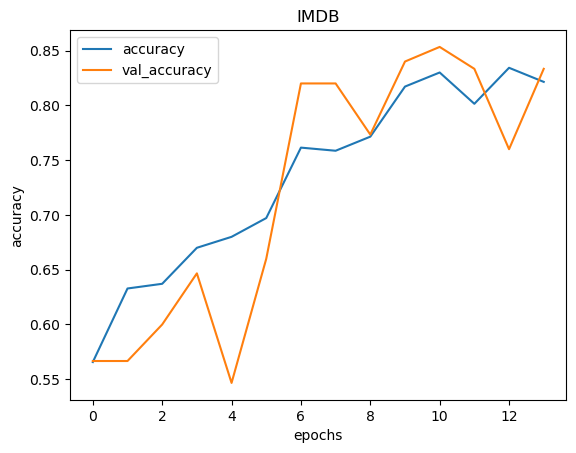

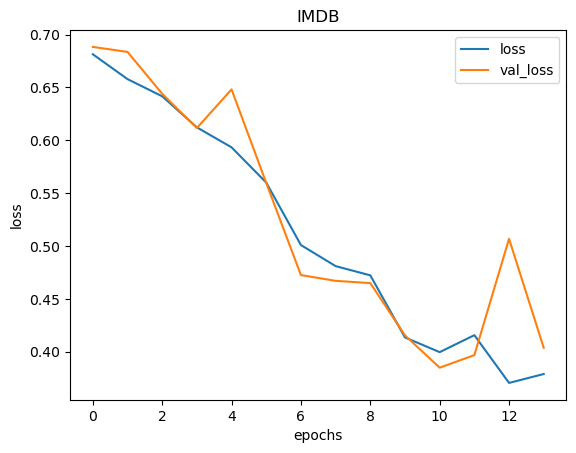

In [212]:
plot_graphs(history_imdb,'accuracy', 'IMDB')
plot_graphs(history_imdb,'loss', 'IMDB')

In [213]:
print("IMDB")
evaluate_classifier(model_imdb, X_test_text_imdb, y_test_imdb)

IMDB
5/5 [==============================] - 3s 518ms/step
Accuracy: 0.900
F1 score: 0.900


(0.9, 0.8999955553580159)

Addestriamo e valutiamo sul dominio yelp.

In [218]:
model_yelp = build_bert_classifier()

In [219]:
from tf_keras.callbacks import EarlyStopping

history_yelp = model_yelp.fit(
    X_train_text_yelp, y_train_yelp,
    validation_data=(X_val_text_yelp, y_val_yelp),
    epochs=30,
    verbose=1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
)

Epoch 1/30
22/22 [==============================] - 17s 699ms/step - loss: 0.6861 - accuracy: 0.5343 - val_loss: 0.6587 - val_accuracy: 0.5733
Epoch 2/30
22/22 [==============================] - 14s 660ms/step - loss: 0.6541 - accuracy: 0.6229 - val_loss: 0.6285 - val_accuracy: 0.6867
Epoch 3/30
22/22 [==============================] - 14s 660ms/step - loss: 0.6201 - accuracy: 0.6586 - val_loss: 0.5700 - val_accuracy: 0.7267
Epoch 4/30
22/22 [==============================] - 14s 661ms/step - loss: 0.5621 - accuracy: 0.7114 - val_loss: 0.5345 - val_accuracy: 0.7600
Epoch 5/30
22/22 [==============================] - 14s 659ms/step - loss: 0.4710 - accuracy: 0.7957 - val_loss: 0.5082 - val_accuracy: 0.7667
Epoch 6/30
22/22 [==============================] - 14s 656ms/step - loss: 0.4731 - accuracy: 0.7800 - val_loss: 0.5438 - val_accuracy: 0.7400
Epoch 7/30
22/22 [==============================] - 14s 664ms/step - loss: 0.4632 - accuracy: 0.7729 - val_loss: 0.4198 - val_accuracy: 0.8467

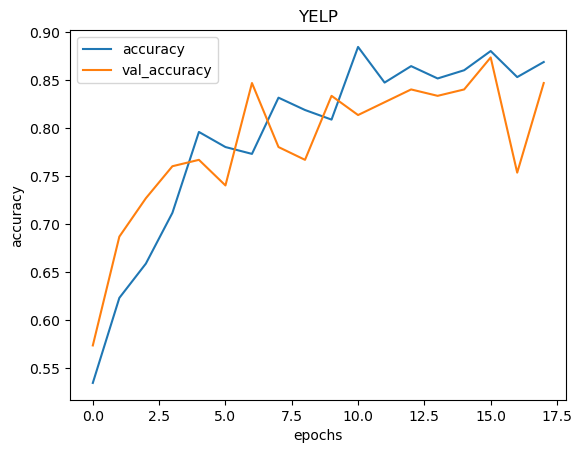

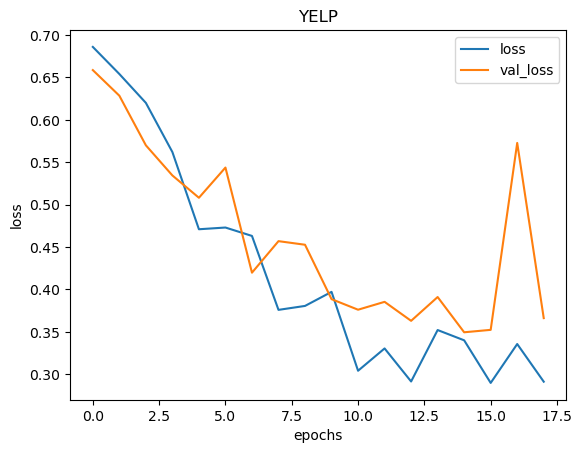

In [220]:
plot_graphs(history_yelp,'accuracy', 'YELP')
plot_graphs(history_yelp,'loss', 'YELP')

In [221]:
print("YELP")
evaluate_classifier(model_yelp, X_test_text_yelp, y_test_yelp)

YELP
5/5 [==============================] - 3s 527ms/step
Accuracy: 0.833
F1 score: 0.833


(0.8333333333333334, 0.8332666399893291)

Addestriamo e valutiamo sul dataset unificato.

In [230]:
model = build_bert_classifier()

In [231]:
from tf_keras.callbacks import EarlyStopping

history = model.fit(
    X_train_text, y_train,
    validation_data=(X_val_text, y_val),
    epochs=30,
    verbose=1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
)

Epoch 1/30
44/44 [==============================] - 31s 673ms/step - loss: 0.6756 - accuracy: 0.5671 - val_loss: 0.6530 - val_accuracy: 0.6033
Epoch 2/30
44/44 [==============================] - 29s 656ms/step - loss: 0.6364 - accuracy: 0.6329 - val_loss: 0.5924 - val_accuracy: 0.7067
Epoch 3/30
44/44 [==============================] - 29s 657ms/step - loss: 0.5617 - accuracy: 0.7193 - val_loss: 0.5905 - val_accuracy: 0.6667
Epoch 4/30
44/44 [==============================] - 29s 664ms/step - loss: 0.5037 - accuracy: 0.7450 - val_loss: 0.4587 - val_accuracy: 0.8000
Epoch 5/30
44/44 [==============================] - 29s 658ms/step - loss: 0.4883 - accuracy: 0.7564 - val_loss: 0.5747 - val_accuracy: 0.6633
Epoch 6/30
44/44 [==============================] - 29s 659ms/step - loss: 0.4163 - accuracy: 0.8071 - val_loss: 0.3552 - val_accuracy: 0.8633
Epoch 7/30
44/44 [==============================] - 29s 658ms/step - loss: 0.3879 - accuracy: 0.8321 - val_loss: 0.4064 - val_accuracy: 0.8067

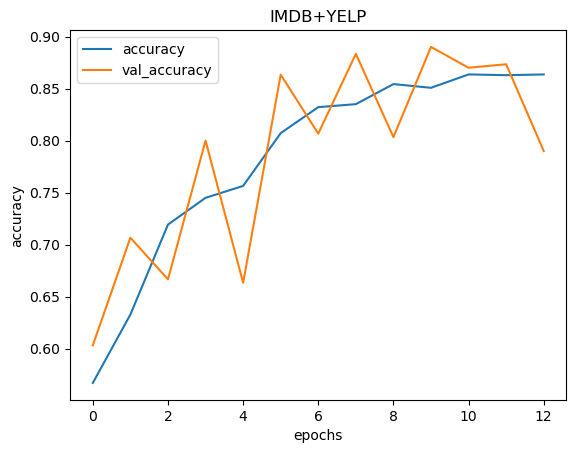

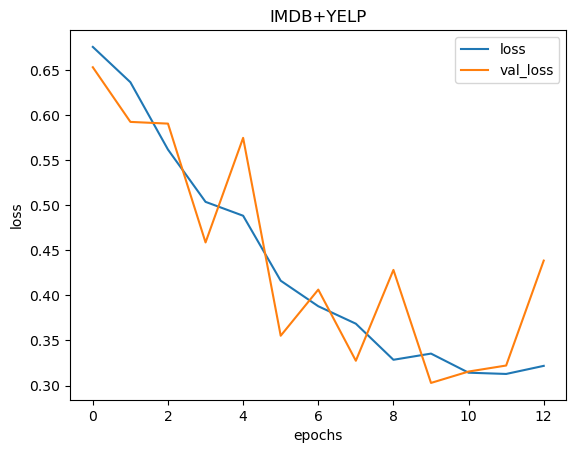

In [232]:
plot_graphs(history,'accuracy', 'IMDB+YELP')
plot_graphs(history,'loss', 'IMDB+YELP')

In [233]:
print("IMDB+YELP")
evaluate_classifier(model, X_test_text, y_test)

IMDB+YELP
10/10 [==============================] - 5s 524ms/step
Accuracy: 0.870
F1 score: 0.870


(0.87, 0.8698249869268684)

BERT con fine-tuning risulta essere il modello migliore tra tutti quelli considerati, su entrambi i domini e sul dataset unificato, con prestazioni che superano largamente quelli della baseline considerata. Il congelamento dei pesi dell'encoder, con il solo training del classificatore on top, permettano di avere un numero contenuto di parametri da addestrare, e quindi un costo computazionale a training time  (e anche a inferenza) contenuto. Gli ottimi risultati ottenuti da questo modello derivano dalla conoscenza pregressa di grammatica, semantica e sintassi del linguaggio (in particolare in lingua inglese) ottenuta grazie al pre-training su un corpus molto vasto di documenti. Questo permette al modello di costruire delle rappresentazioni contestuali che portano con sè significative relazioni sintattico-semantiche tra ogni parola e il contesto in cui compare. Grazie al fine-tuning inoltre il modello (il classificatore on top) si adatta allo specifico task, permettendo di specializzare le conoscenze linguistiche possedute da BERT, e le rappresentazioni contestuali costruite, sul task di sentiment analysis considerato, e superando il problema del dataset di dimensione ridotta a disposizione, presente invece nel momento in cui un modello deve essere addestrato da zero.
Inoltre questo modello riesce a evitare completamente il problema dell'overfitting, in parte riscontrato nei modelli precedenti, come dimostrato dalle curve di apprendimento ottenute.

In [234]:
print_nn_domain_accuracy(
    model=model, 
    X_input=X_test_text,
    y_true=y_test, 
    X_original_text=X_test_text, 
    data_df=data
)


Accuratezza per dominio:
Dominio IMDB: 124/150 corretti (82.67%)
Dominio YELP: 137/150 corretti (91.33%)




Come per i modelli precedenti, anche BERT riesce a migliorare le prestazioni sul dominio yelp grazie a fine-tuning su dataset unificato.

In [235]:
log_neural_performance("BERT+fine-tuning", 
                       model_imdb, X_test_text_imdb, y_test_imdb,
                       model_yelp, X_test_text_yelp, y_test_yelp,
                       model, X_test_text, y_test)

Risultati per 'BERT+fine-tuning' salvati su CSV.


## Dataset augmentation

Un ultimo esperimento che viene condotto è quello della dataset augmentation. Un'altra strategia per superare il problema dei pochi dati di training a disposizione, con l'obiettivo di migliorare le capacità di generalizzazione di un modello, è aumentare il numero di esempi nel training set producendo dati sintetici, ossia generati a partire dai dati nel training set originale. Questo meccanismo può essere anche realizzato nell'ambito del NLP, in particolare andando a creare nuove frasi a partire da quelle presenti nel training set, tramite sostituzione di termini con sinonimi, rimozione o swap randomico tra termini, oppure inserimento di sinomini (o anche altre tecniche che possono essere esplorate).
<br>
Poichè l'obiettivo è di aumentare la dimensione del dataset, si è deciso di considerare esclusivamente il dataset unificato, che quindi massimizza la dimensione del training set di partenza. A partire da questo training set, è stato generato un nuovo set "aumentato" sinteticamente. Validation set e test set sono stati mantenuti invariati, poichè le capacità di generalizzazione del modello devono essere valutate su dati reali (come quelli con cui a inferenza il modello potrebbe avere a che fare), non prodotti sintenticamente.
<br>
Per produrre le frasi sintetiche, in particolare per individuare i sinonimi, si utilizza WordNet, un database lessicale in Inglese.

In [236]:
import random
import pandas as pd
import nltk
from nltk.corpus import wordnet, stopwords

nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))

# Restituisce la lista dei sinonimi di una parola 
def get_synonyms(word):
    synonyms = set()
    # Ottiene l'insieme dei sinonimi della parola
    for syn in wordnet.synsets(word):
        # Considera ogni lemma (ossia forma possibile della parola)
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            # Ignora la parola originale e parole composte da numeri o simboli
            if synonym != word and synonym.isalpha():
                synonyms.add(synonym)
    return list(synonyms)

# Sostituisce n parole con un loro sinonimo
def synonym_replacement(sentence, rnd, n=1):

    words = sentence.split()
    new_words = words.copy()

    # parole candidate (non stopwords)
    candidate_words = [w for w in words if w.lower() not in stop_words]

    rnd.shuffle(candidate_words)
    num_replaced = 0

    for word in candidate_words:
        # Recupera i sinonimi della parola
        synonyms = get_synonyms(word.lower())

        # Sceglie casualmente uno dei sinonimi
        if len(synonyms) >= 1:
            synonym = rnd.choice(synonyms)
            new_words = [synonym if w == word else w for w in new_words]
            num_replaced += 1

        if num_replaced >= n:
            break

    return " ".join(new_words)


# Rimuove parole dalla frase con probabilità pari a p
def random_deletion(sentence, rnd, p=0.2):
    words = sentence.split()
    # Se la fase contiene una sola parola, non realizza alcuna eliminazione
    if len(words) == 1:
        return sentence
    # Per ogni parola, produce un valore tra 0 e 1, se maggiore di p, la parola viene rimossa    
    new_words = [w for w in words if rnd.random() > p]
    # Se tutte le parole sono state eliminate, sceglie casualmente una parola dalla frase originale e restituisce quella
    if not new_words:
        return rnd.choice(words)
    return ' '.join(new_words)

# Realizza n swap tra parole in una frase
def random_swap(sentence, rnd, n=1):
    words = sentence.split()
    new_words = words.copy()
    # Esegue n swap casuali
    for _ in range(n):
        # Se la frase ha meno di due parole non si può fare uno swap
        if len(words) < 2:
            break
        # Sceglie casualmente due indici   
        idx1, idx2 = rnd.sample(range(len(words)), 2)
        # Swap delle parole
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return ' '.join(new_words)

# Inserisce n sinonimi di parole presenti nella frase
def random_insertion(sentence, rnd, n=1):
    words = sentence.split()
    new_words = words.copy()
    # Esegue n inserimenti
    for _ in range(n):
        # Seleziona casualmente la posizione dove realizzare l'inserimento
        idx = rnd.randrange(len(new_words)+1)
        # Sceglie casualmente una parola della frase
        word = rnd.choice(words)
        # Recupera i sinonimi tramite WordNet
        synonyms = wordnet.synsets(word.lower())
        # Rimuove la parola originale tra i sinonimi
        valid_synonyms = [lemma.name().replace("_", " ").lower() 
                          for syn in synonyms for lemma in syn.lemmas()
                          if lemma.name().lower() != word.lower()]
        # Sceglie un sinonimo casualmente e lo inserisce nella posizione selezionata 
        if valid_synonyms:
            new_words.insert(idx, rnd.choice(valid_synonyms))
    return ' '.join(new_words)

# Produce due frasi sintenticamente a partire da una frase originale    
def augment_sentence_multiple(sentence, seed=None):
    rnd = random.Random(seed)
    
    # Augmentation 1: synonym + deletion
    aug1 = synonym_replacement(sentence, rnd, n=1)
    aug1 = random_deletion(aug1, rnd, p=0.1)
    
    # Augmentation 2: swap + insertion
    aug2 = random_swap(sentence, rnd, n=1)
    aug2 = random_insertion(aug2, rnd, n=1)
    
    return aug1, aug2

X_train_aug = []
y_train_aug = []

for review, sentiment in zip(X_train_text, y_train):
    # Inserisce nel training set le frasi originali
    X_train_aug.append(review)
    y_train_aug.append(sentiment)
    
    # Inserisce nel training set le frasi prodotte sinteticamente
    aug1, aug2 = augment_sentence_multiple(review, seed=2026)
    X_train_aug.extend([aug1, aug2])
    y_train_aug.extend([sentiment, sentiment])


X_train_aug = pd.Series(X_train_aug)
y_train_aug = pd.Series(y_train_aug)

[nltk_data] Downloading package wordnet to /home/matteo/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/matteo/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Poichè per ogni frase originale produce due frasi tramite augmentation, la dimensione del nuovo training set risulta triplicata.

In [237]:
print(f"Training set originale: {len(X_train_text)}, Training set aumentato: {len(X_train_aug)}")

Training set originale: 1400, Training set aumentato: 4200


Visualizziamo alcune delle frasi prodotte tramite augmentation.

In [238]:
import pandas as pd

examples = []

# Prendiamo i primi 5 gruppi (quindi 15 frasi)
for i in range(0, 9, 3):
    examples.append({
        "Originale": X_train_aug[i],
        "Augmentation 1": X_train_aug[i+1],
        "Augmentation 2": X_train_aug[i+2],
        "Label": y_train_aug[i]
    })
    
pd.set_option('display.max_colwidth', None) 
df_examples = pd.DataFrame(examples)
df_examples

,Originale,Augmentation 1,Augmentation 2,Label
0,my first visit to hiro was a delight,my first visit to hiro was a pleasure,joy my delight visit to hiro was a first,1
1,this would not even be good as a made for tv flick,this would not even be good as a made for telecasting flick,this would not even be as good a made for tv crap flick,0
2,avoid at any and all costs,avoid at any and all toll,avoid at any all and costs,0


Consideriamo il modello migliore tra tutti quelli presentati, ossia BERT con fine-tuning, e andiamo a realizzare il fine-tuning utilizzando il training set aumentato.

In [239]:
model = build_bert_classifier()

In [240]:
model.summary()

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_8 (InputLayer)        [(None,)]                    0         []                            
                                                                                                  
 keras_layer (KerasLayer)    {'input_type_ids': (None,    0         ['input_8[0][0]']             
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                            

In [241]:
from tf_keras.callbacks import EarlyStopping

history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val_text, y_val),
    epochs=40,
    verbose=1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
)

Epoch 1/40
132/132 [==============================] - 77s 573ms/step - loss: 0.6596 - accuracy: 0.6036 - val_loss: 0.5891 - val_accuracy: 0.7900
Epoch 2/40
132/132 [==============================] - 75s 572ms/step - loss: 0.5574 - accuracy: 0.7055 - val_loss: 0.4136 - val_accuracy: 0.8400
Epoch 3/40
132/132 [==============================] - 76s 574ms/step - loss: 0.4696 - accuracy: 0.7731 - val_loss: 0.3533 - val_accuracy: 0.8767
Epoch 4/40
132/132 [==============================] - 76s 576ms/step - loss: 0.4253 - accuracy: 0.8048 - val_loss: 0.3104 - val_accuracy: 0.8867
Epoch 5/40
132/132 [==============================] - 76s 576ms/step - loss: 0.4039 - accuracy: 0.8164 - val_loss: 0.3213 - val_accuracy: 0.8567
Epoch 6/40
132/132 [==============================] - 76s 576ms/step - loss: 0.3772 - accuracy: 0.8324 - val_loss: 0.3427 - val_accuracy: 0.8633
Epoch 7/40
132/132 [==============================] - 76s 577ms/step - loss: 0.3826 - accuracy: 0.8288 - val_loss: 0.3138 - val_ac

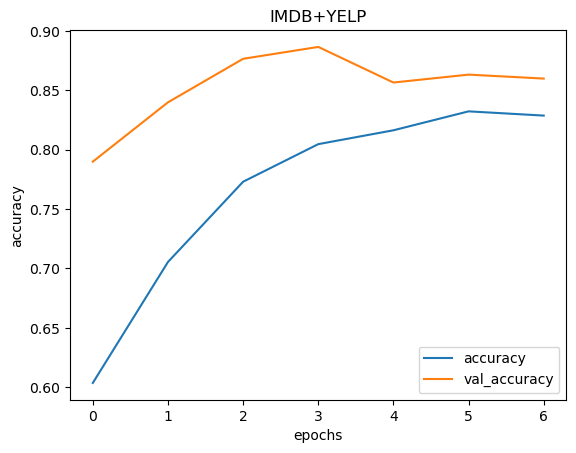

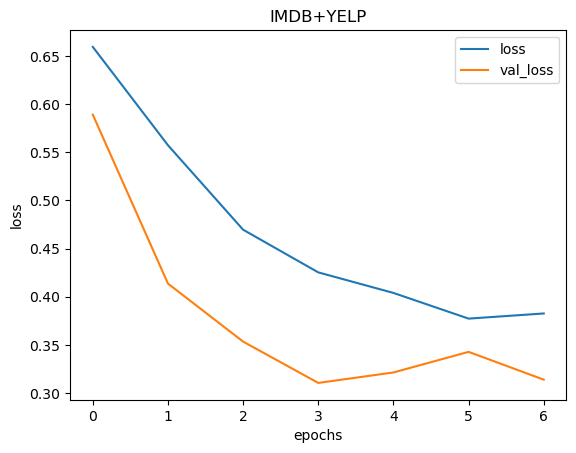

In [242]:
plot_graphs(history,'accuracy', 'IMDB+YELP')
plot_graphs(history,'loss', 'IMDB+YELP')

In [243]:
print("IMDB+YELP")
evaluate_classifier(model, X_test_text, y_test)

IMDB+YELP
10/10 [==============================] - 5s 518ms/step
Accuracy: 0.877
F1 score: 0.877


(0.8766666666666667, 0.8766652962810697)

In conclusione utilizzando dataset augmentation sul modello migliore ottenuto nel notebook, ossia BERT con fine-tuning, non si ottengono risultati drasticamente migliori per quanto riguarda l'accuratezza sul test set. Probabilmente ciò è dovuto al fatto che le frasi prodotte sintenticamente non permettono al modello di acquisire maggiori capacità di estrarre il sentiment dalle recensioni in input. Spesso infatti l'augmentation dal punto di vista lessicale può essere ridondante (sostituzione o aggiunta di sinonimi, swap o rimozioni randomiche), realizzando operazioni che producono variazioni superficiali, che quindi non modificano realmente la semantica della frase in input, e generando esempi che trasportano un'informazione molto simile a quella delle frasi originali. Un effettivo miglioramento si potrebbe quindi osservare se si avessero a diposizione un maggiore numero di frasi reali, e quindi non prodotte sinteticamente, da aggiungere al training set, in modo da mostrare al modello modi alternativi per esprimere la propria opinione relativamente ad un film o ad una attività commerciale.
<br>
Osservando l'andamento del training, un vantaggio che si ottiene dall'augmentation è una maggiore velocità con cui il modello raggiunge buone prestazioni. Infatti già alla terza epoca riesce ad ottenere un'accuratezza sul set di validazione di circa l'87%. Inoltre le curve di apprendimento risultano molto più smooth rispetto al case precedente, perchè il maggior numero di esempi produce correzioni dei parametri più a grana fine, e quindi dopo le prime epoche il training porta ad aggiornare di poco la loss per convergere ai parametri ottimali.

# Sintesi Risultati

In conclusione vengono creati dei grafici a barre per visualizzare i risultati ottenuti.

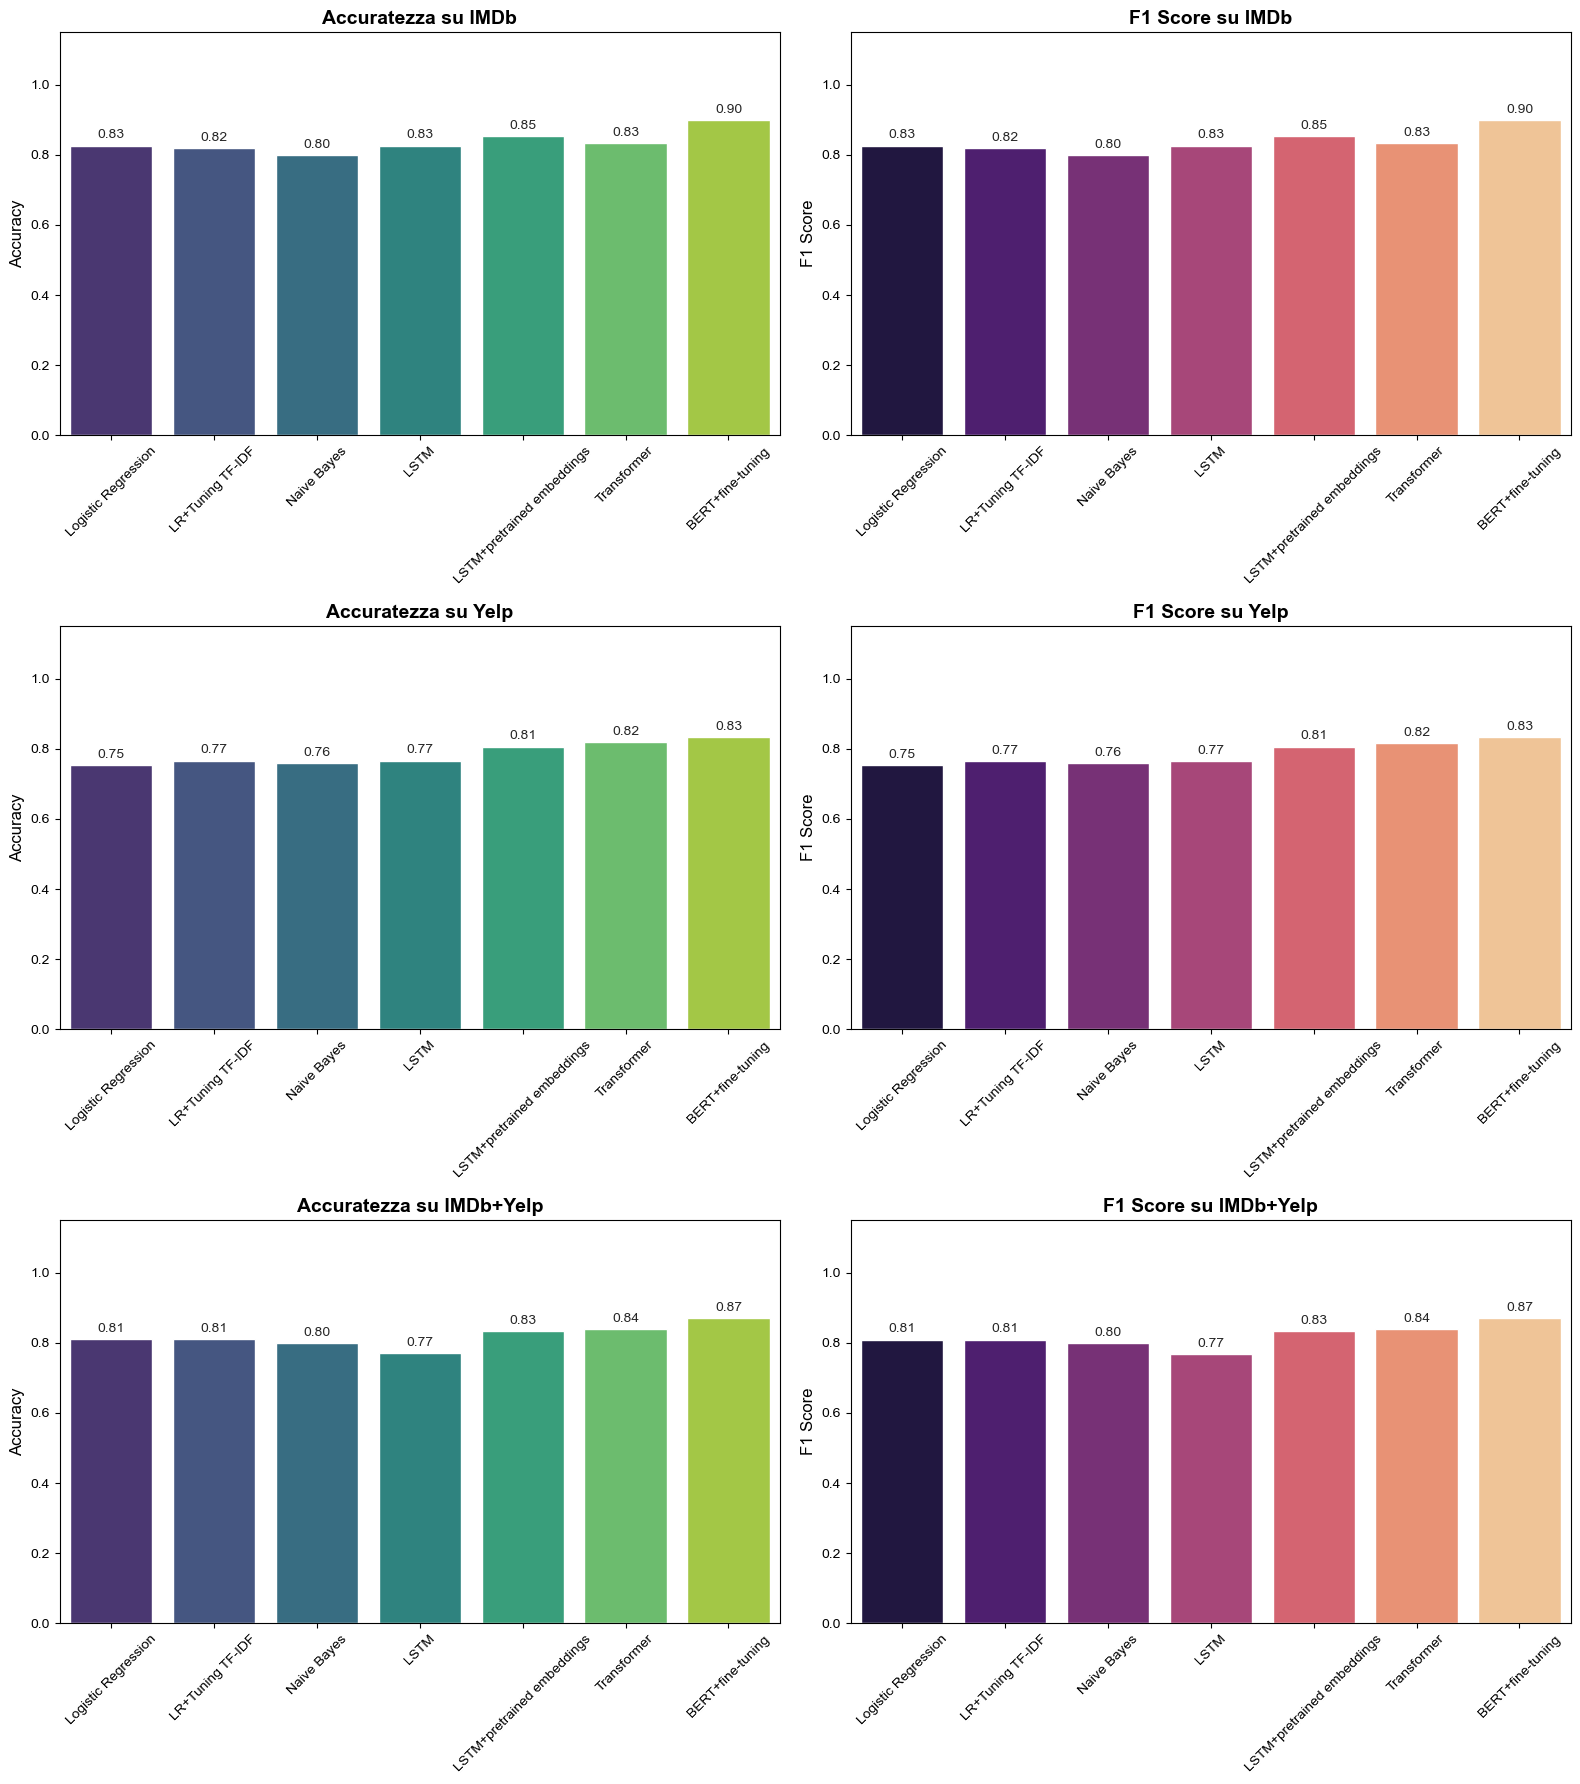

In [244]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_graphs():
    
    ACC_FILE = "accuracy.csv"
    F1_FILE = "f1.csv"

    # Lettura dei dati
    try:
        df_acc = pd.read_csv(ACC_FILE)
        df_f1 = pd.read_csv(F1_FILE)
    except FileNotFoundError:
        print(f"Errore: File {ACC_FILE} o {F1_FILE} non trovati.")
        return

    # Definizione dei domini e configurazione del plot
    domains = ['IMDb', 'Yelp', 'IMDb+Yelp']
    fig, axes = plt.subplots(3, 2, figsize=(16, 18)) # 3 righe, 2 colonne
    
    # Impostazioni stile
    sns.set_theme(style="whitegrid")

    # Ciclo per creare i grafici per ogni dominio
    for i, domain in enumerate(domains):
        # Grafico Accuracy
        ax_acc = axes[i, 0]
        sns.barplot(
            data=df_acc, 
            x='Model', 
            y=domain, 
            hue='Model',     
            legend=False,    
            ax=ax_acc, 
            palette='viridis'
        )
        
        ax_acc.set_title(f'Accuratezza su {domain}', fontsize=14, fontweight='bold')
        ax_acc.set_ylim(0, 1.15)
        ax_acc.set_ylabel('Accuracy', fontsize=12)
        ax_acc.set_xlabel('')
        ax_acc.tick_params(axis='x', rotation=45)
        
        for container in ax_acc.containers:
            ax_acc.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

        # Grafico F1
        ax_f1 = axes[i, 1]
        sns.barplot(
            data=df_f1, 
            x='Model', 
            y=domain, 
            hue='Model',     
            legend=False,   
            ax=ax_f1, 
            palette='magma'
        )
        
        ax_f1.set_title(f'F1 Score su {domain}', fontsize=14, fontweight='bold')
        ax_f1.set_ylim(0, 1.15)
        ax_f1.set_ylabel('F1 Score', fontsize=12)
        ax_f1.set_xlabel('')
        ax_f1.tick_params(axis='x', rotation=45)
        
        for container in ax_f1.containers:
            ax_f1.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

    plt.tight_layout()
    plt.show()


plot_graphs()